<a href="https://colab.research.google.com/github/Andrea-125478/MCD/blob/main/Segunda_limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Replace 'your_file_name.xlsx' with the actual path to your .xlsx file
# For example: df = pd.read_excel('data/my_spreadsheet.xlsx')
df = pd.read_excel('/content/M2 (1).xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,ID,SC,RAZON,FIn,Fter,TASA,ZC,TM,Pt,CP,EC,Md,ISPknn,Plz,MFCZ,M/V,Burden,ISPZ,Unnamed: 18
0,270,ACTIVO,RECUPERACION,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,55060,54,2025,7768.225619,1.013465,2.667896,0.381128,63.280928,0.041599,NaN
1,272,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,7100,62,2025,7768.225619,1.013465,2.667896,0.381128,63.280928,0.041599,NaN
2,1666,ACTIVO,RECUPERACION,2024-08-02,2028-07-28,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,9208,42,2025,8357.681667,1.013465,2.667896,0.381128,6.909962,0.380964,NaN
3,1740,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,52916,39,2025,8154.263333,1.013465,2.667896,0.381128,9.977022,0.263851,NaN
4,1806,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,55749,51,2025,7984.343333,1.013465,2.667896,0.381128,15.855844,0.166024,NaN


### Identificación de tipos de variables

Primero, vamos a identificar los tipos de datos de cada columna en el DataFrame para entender mejor la naturaleza de nuestras variables.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2853 entries, 0 to 2852
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ID           2853 non-null   int64         
 1   SC           2853 non-null   object        
 2   RAZON        2853 non-null   object        
 3   FIn          2853 non-null   datetime64[ns]
 4   Fter         2853 non-null   datetime64[ns]
 5   TASA         2853 non-null   float64       
 6   ZC           2853 non-null   object        
 7   TM           2853 non-null   object        
 8   Pt           2853 non-null   object        
 9   CP           2853 non-null   int64         
 10  EC           2853 non-null   int64         
 11  Md           2853 non-null   int64         
 12  ISPknn       2853 non-null   float64       
 13  Plz          2853 non-null   float64       
 14  MFCZ         2853 non-null   float64       
 15  M/V          2853 non-null   float64       
 16  Burden

### Visualización de la distribución de variables numéricas

Ahora, generaremos histogramas para ver la distribución de cada variable numérica y diagramas de caja (box plots) para identificar la mediana, los cuartiles y los posibles valores atípicos.

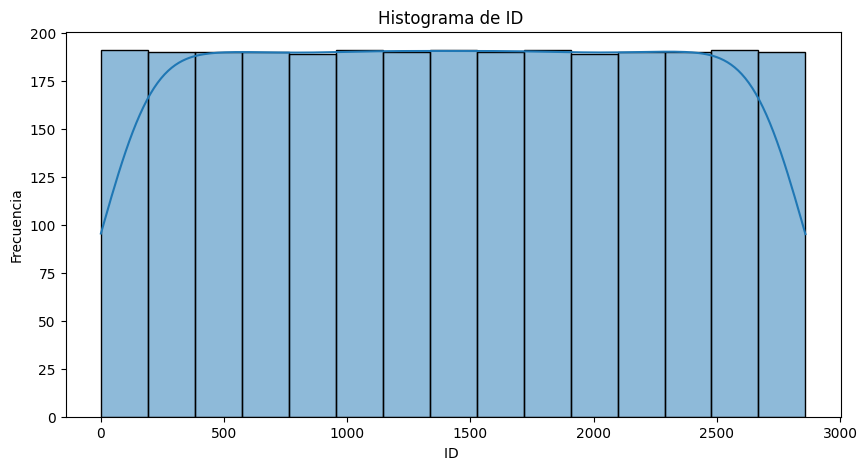

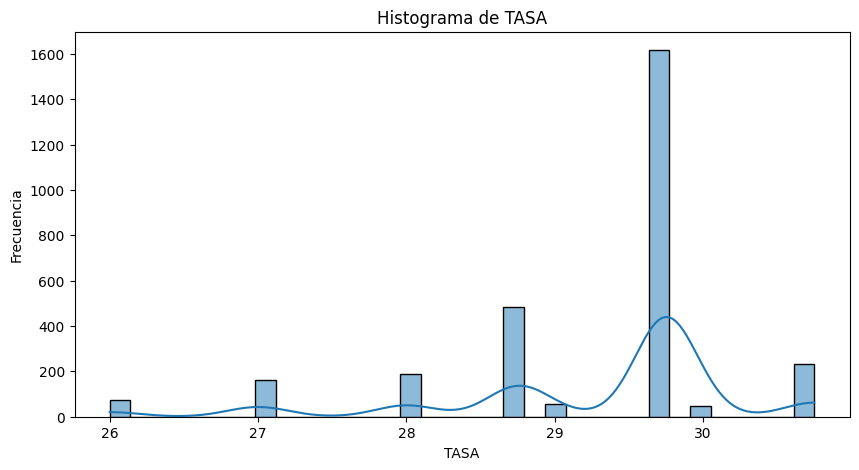

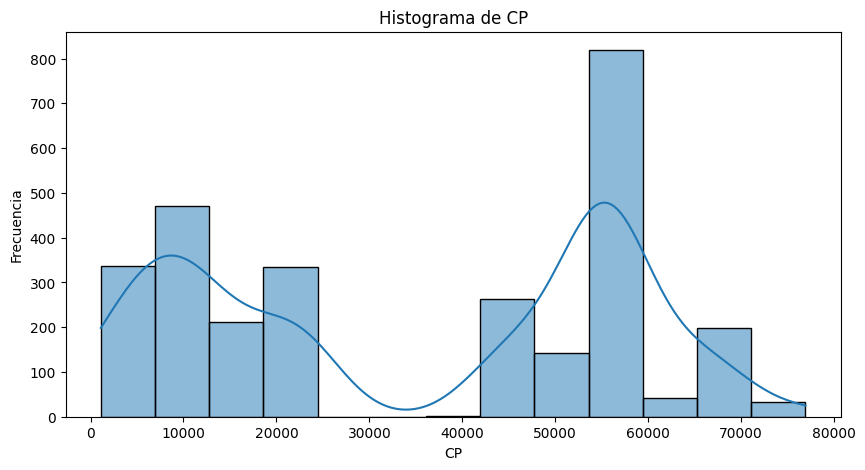

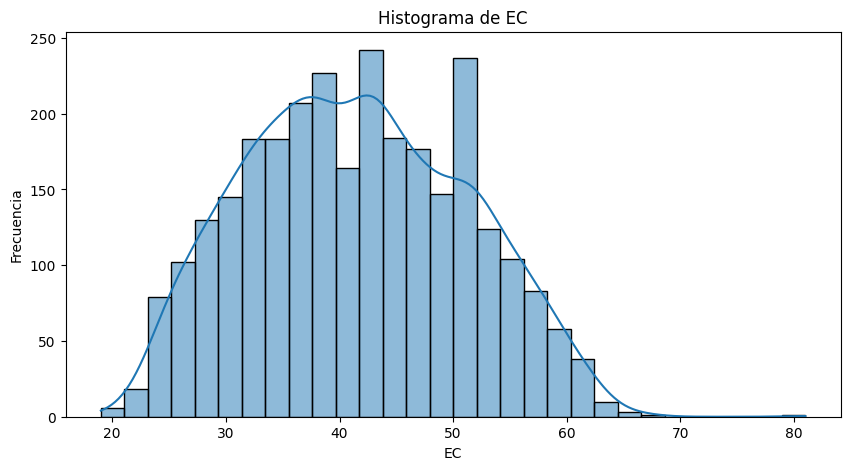

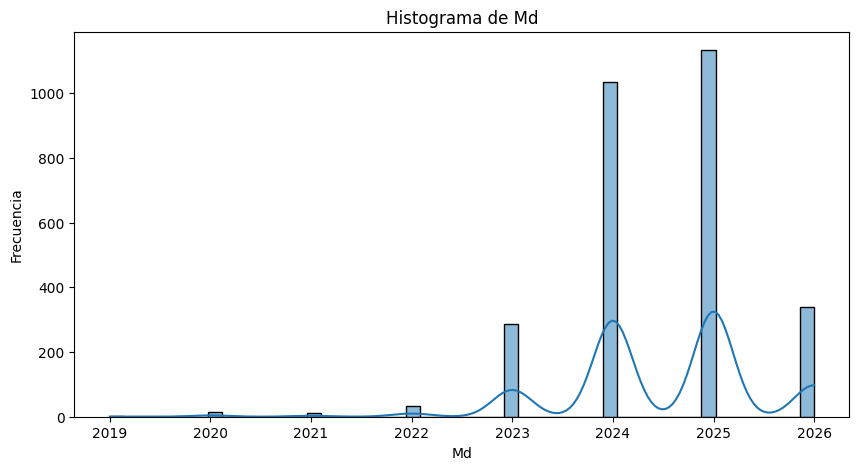

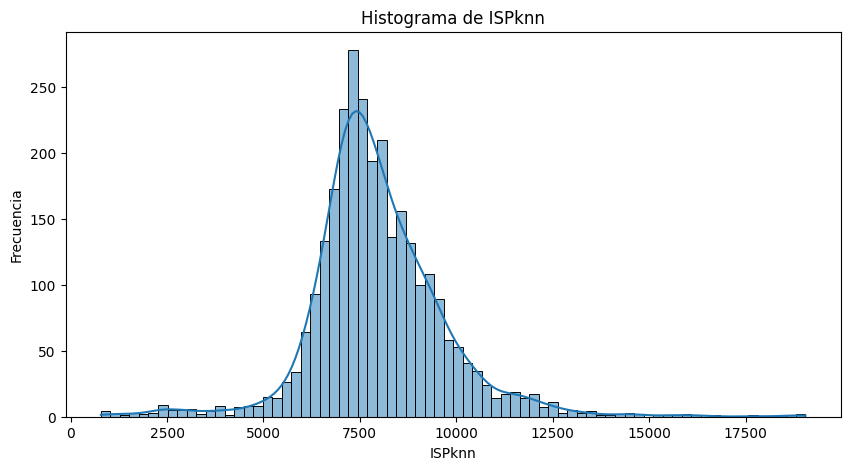

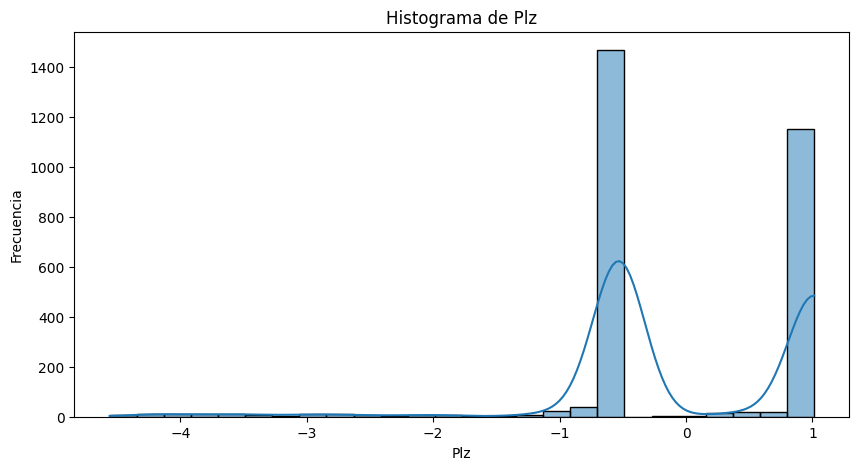

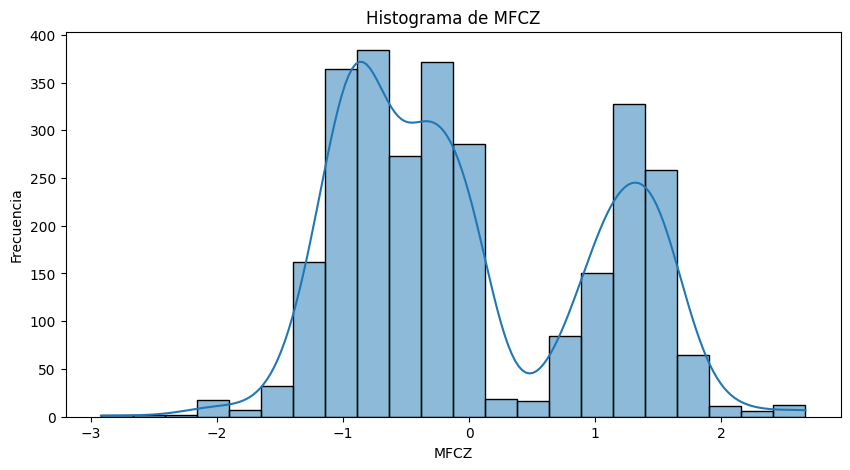

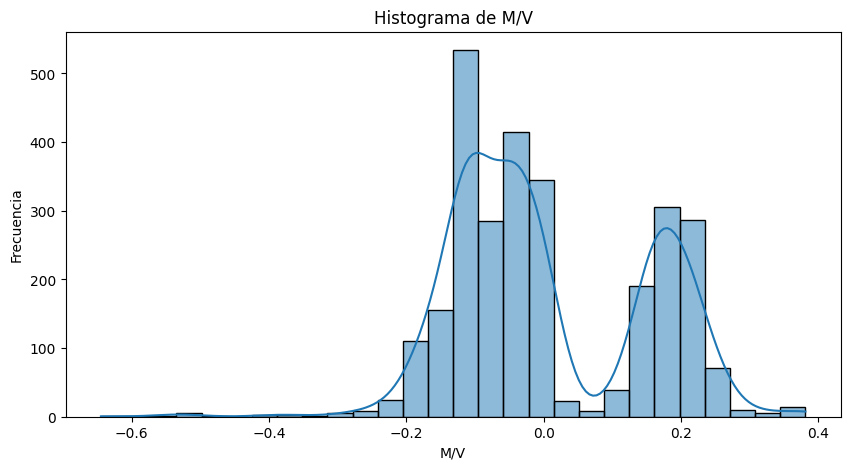

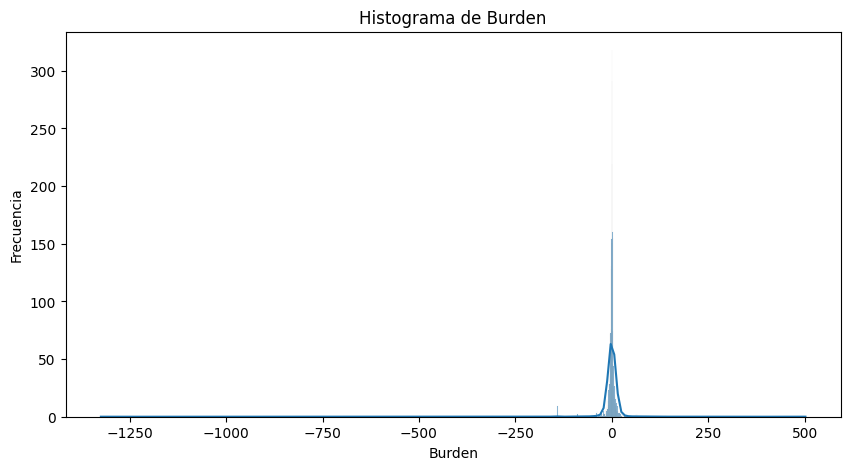

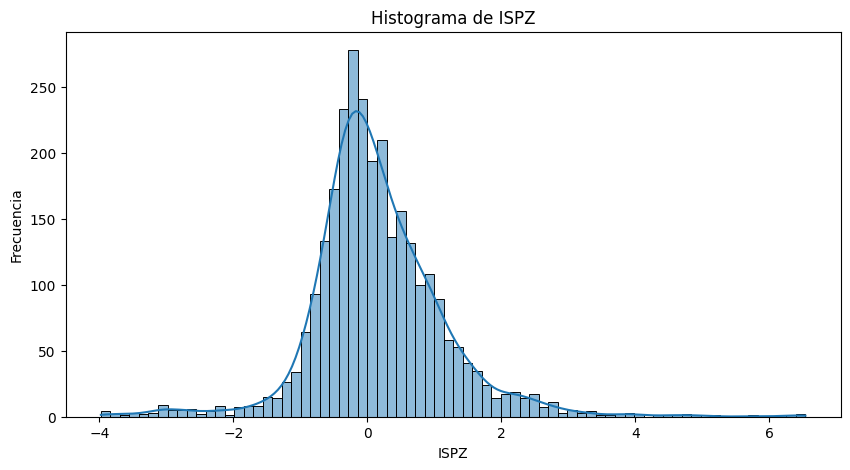

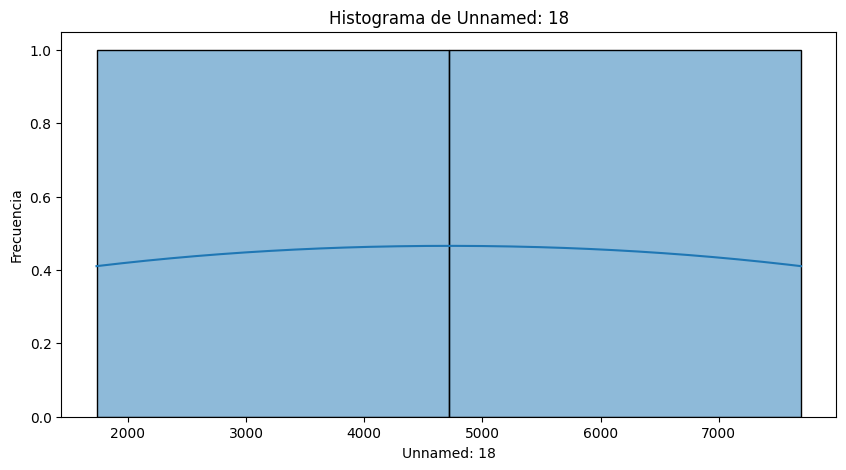

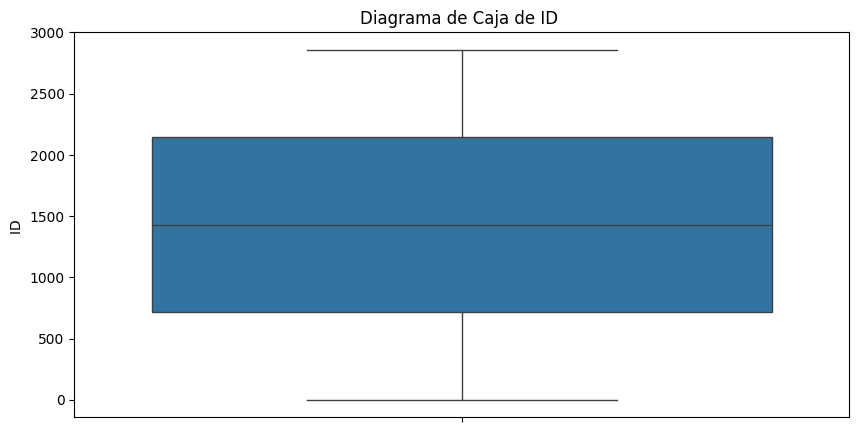

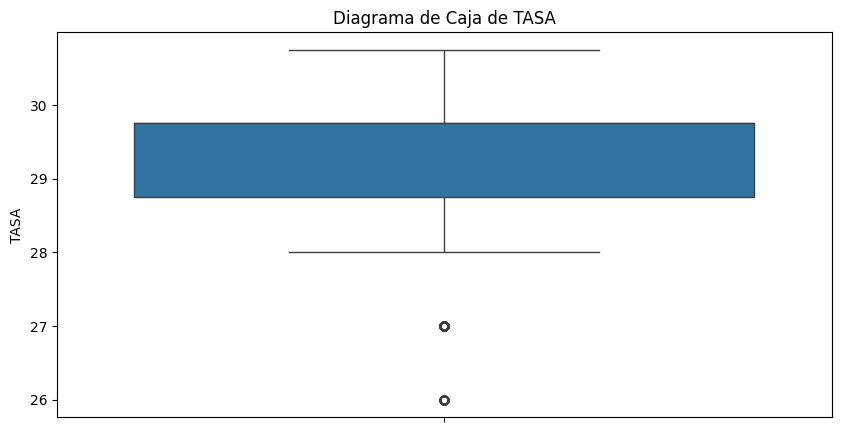

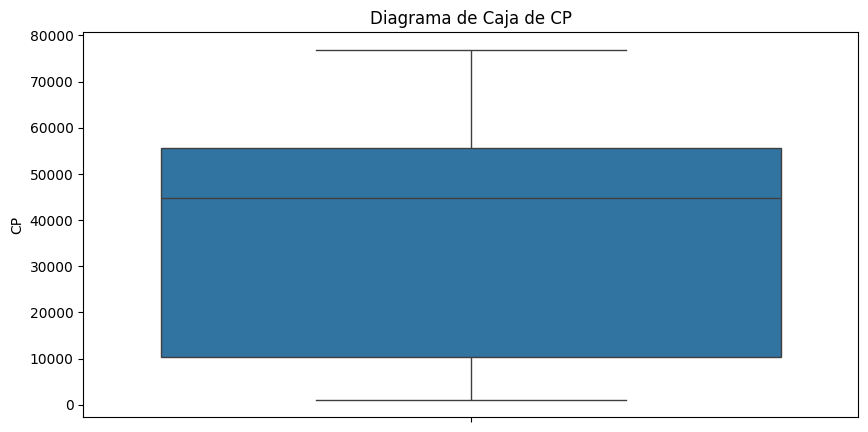

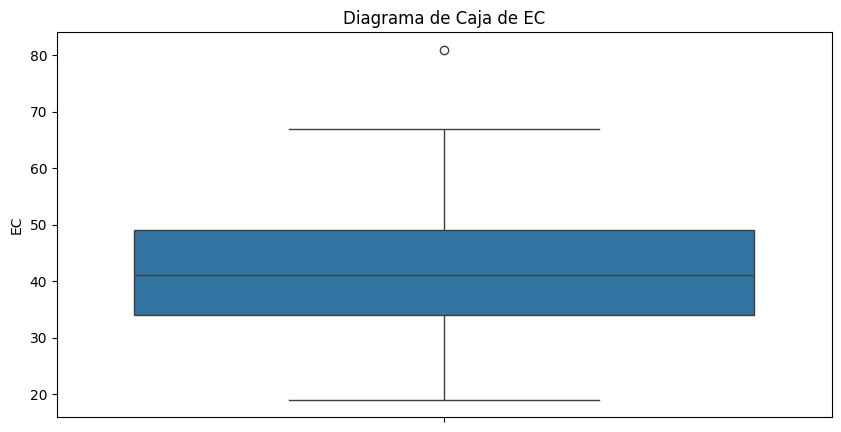

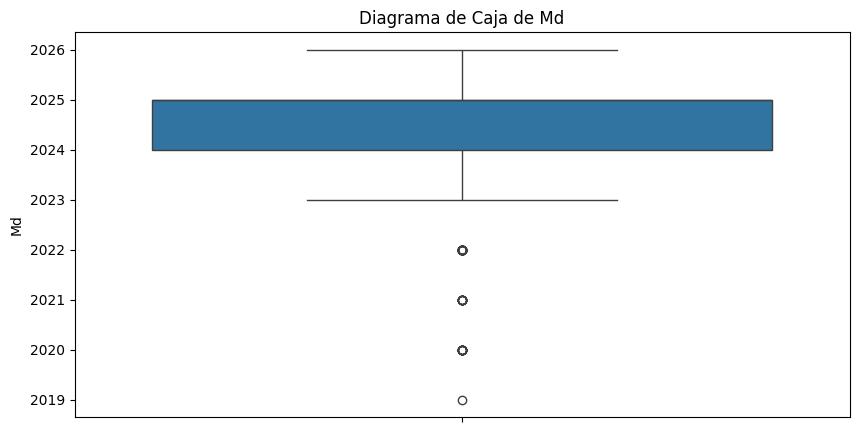

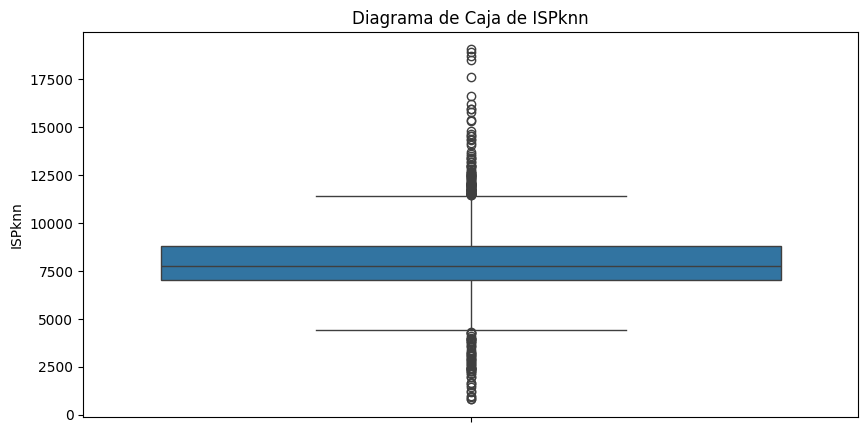

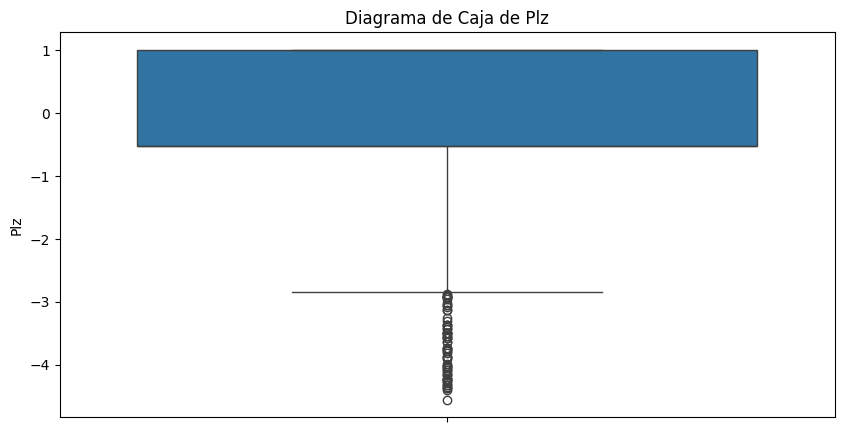

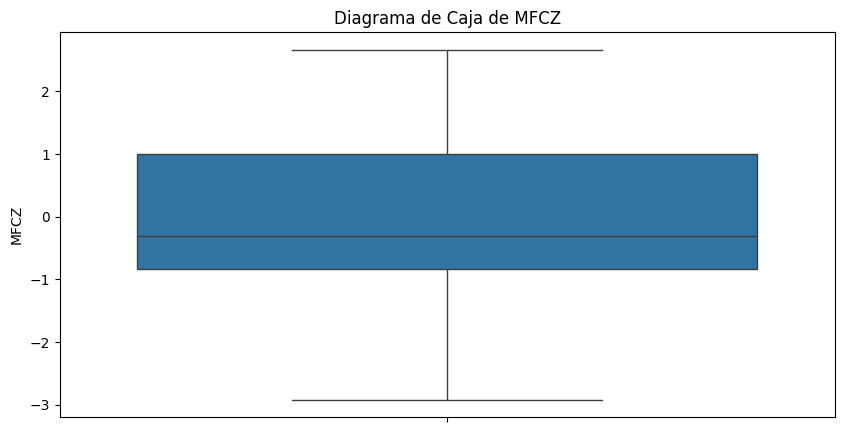

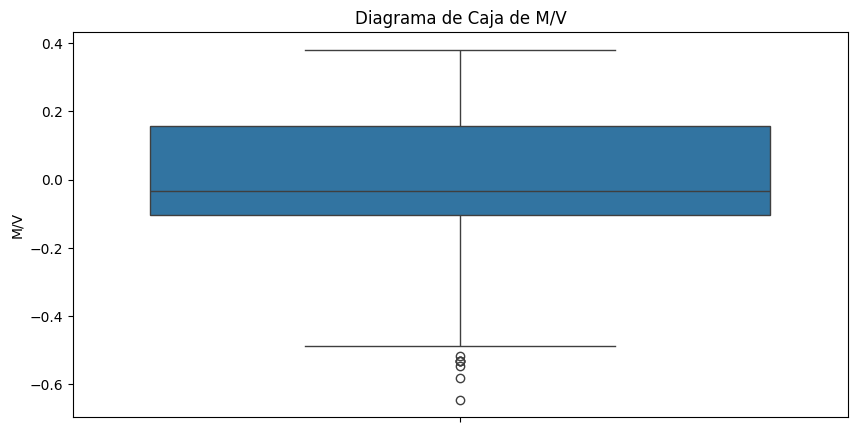

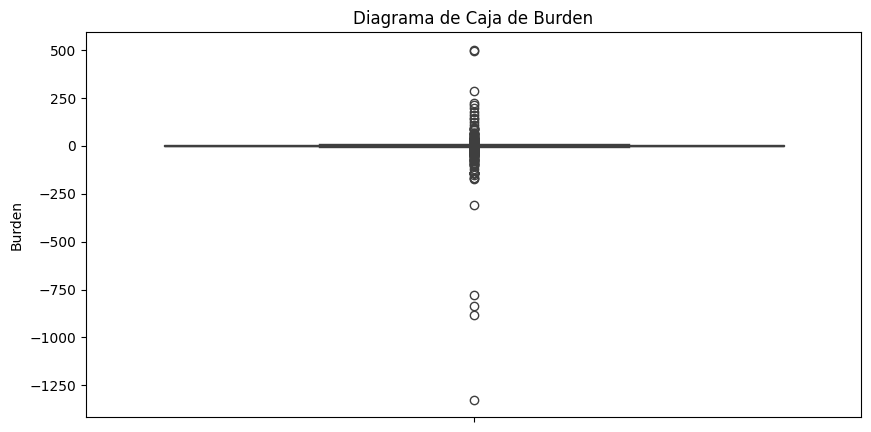

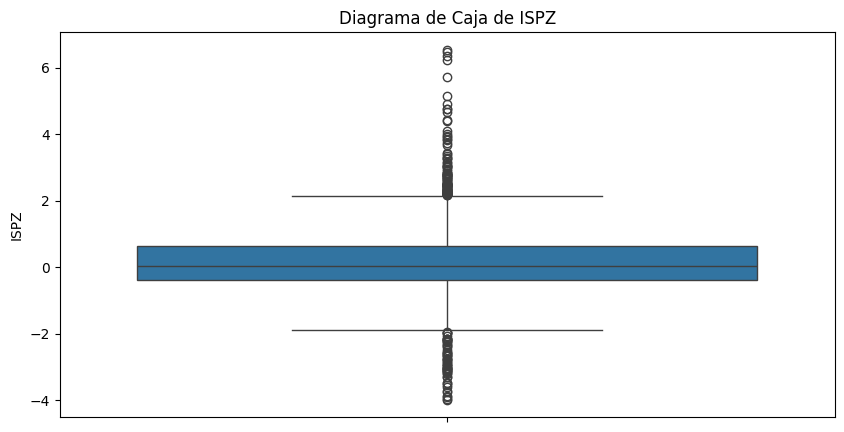

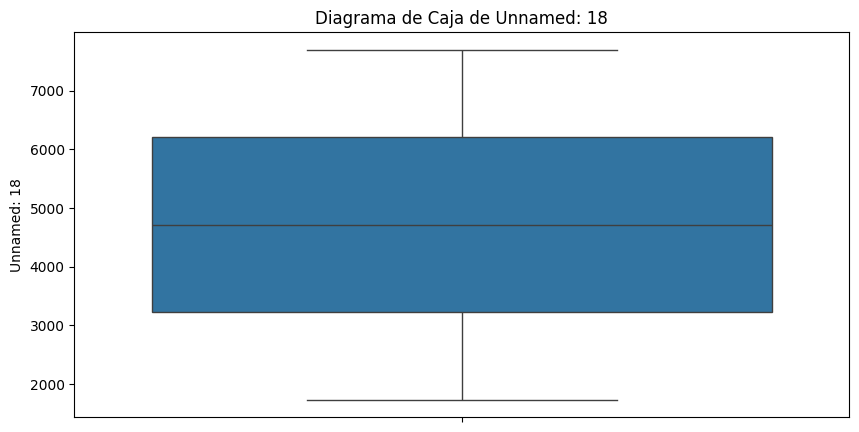

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas
numerical_cols = df.select_dtypes(include=['number']).columns

# Crear histogramas para cada columna numérica
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

# Crear diagramas de caja (box plots) para cada columna numérica
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Diagrama de Caja de {col}')
    plt.ylabel(col)
    plt.show()

### Preparación y Estandarización de Datos

Procederemos a estandarizar las columnas numéricas especificadas, convertir columnas a tipo categórico y eliminar las columnas innecesarias como `ID` y `Unnamed: 18`.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Columns to standardize and their new names
columns_to_standardize = {
    'M/V': 'MVZ',
    'Burden': 'BurdenZ',
    'EC': 'ECZ',
    'TASA': 'TZ'
}

# Apply standardization
for col, new_col_name in columns_to_standardize.items():
    # Ensure the column exists and handle potential NaN values if necessary
    # For standardization, it's generally best to fill NaNs or drop rows before fitting
    # Assuming no NaNs in these columns based on df.info() except 'Unnamed: 18'
    df[new_col_name] = scaler.fit_transform(df[[col]])


display(df.head())

,ID,SC,RAZON,FIn,Fter,TASA,ZC,TM,Pt,CP,...,Plz,MFCZ,M/V,Burden,ISPZ,Unnamed: 18,MVZ,BurdenZ,ECZ,TZ
0,270,ACTIVO,RECUPERACION,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,55060,...,1.013465,2.667896,0.381128,63.280928,0.041599,NaN,2.651384,1.488050,1.301948,0.456661
1,272,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,7100,...,1.013465,2.667896,0.381128,63.280928,0.041599,NaN,2.651384,1.488050,2.134435,0.456661
2,1666,ACTIVO,RECUPERACION,2024-08-02,2028-07-28,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,9208,...,1.013465,2.667896,0.381128,6.909962,0.380964,NaN,2.651384,0.194868,0.053216,0.456661
3,1740,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,52916,...,1.013465,2.667896,0.381128,9.977022,0.263851,NaN,2.651384,0.265228,-0.258967,0.456661
4,1806,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,55749,...,1.013465,2.667896,0.381128,15.855844,0.166024,NaN,2.651384,0.400091,0.989765,0.456661


In [ ]:
# Convert 'Md' and 'CP' to categorical type
df['Md'] = df['Md'].astype('category')
df['CP'] = df['CP'].astype('category')

# Drop 'ID' and 'Unnamed: 18' columns, ignoring errors if they don't exist
df = df.drop(columns=['ID', 'Unnamed: 18'], errors='ignore')

# Display the first 5 rows and info of the modified DataFrame
display(df.head())
print(df.info())

,ID,SC,RAZON,FIn,Fter,TASA,ZC,TM,Pt,CP,...,ISPknn,Plz,MFCZ,M/V,Burden,ISPZ,MVZ,BurdenZ,ECZ,TZ
0,270,ACTIVO,RECUPERACION,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,55060,...,7768.225619,1.013465,2.667896,0.381128,63.280928,0.041599,2.651384,1.488050,1.301948,0.456661
1,272,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,7100,...,7768.225619,1.013465,2.667896,0.381128,63.280928,0.041599,2.651384,1.488050,2.134435,0.456661
2,1666,ACTIVO,RECUPERACION,2024-08-02,2028-07-28,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,9208,...,8357.681667,1.013465,2.667896,0.381128,6.909962,0.380964,2.651384,0.194868,0.053216,0.456661
3,1740,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,52916,...,8154.263333,1.013465,2.667896,0.381128,9.977022,0.263851,2.651384,0.265228,-0.258967,0.456661
4,1806,ACTIVO,ACTIVO,2024-07-31,2028-07-26,29.75,CDMX Y AREA METROPOLITANA,EV,UBER,55749,...,7984.343333,1.013465,2.667896,0.381128,15.855844,0.166024,2.651384,0.400091,0.989765,0.456661


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2853 entries, 0 to 2852
Data columns (total 22 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ID       2853 non-null   int64         
 1   SC       2853 non-null   object        
 2   RAZON    2853 non-null   object        
 3   FIn      2853 non-null   datetime64[ns]
 4   Fter     2853 non-null   datetime64[ns]
 5   TASA     2853 non-null   float64       
 6   ZC       2853 non-null   object        
 7   TM       2853 non-null   object        
 8   Pt       2853 non-null   object        
 9   CP       2853 non-null   category      
 10  EC       2853 non-null   int64         
 11  Md       2853 non-null   category      
 12  ISPknn   2853 non-null   float64       
 13  Plz      2853 non-null   float64       
 14  MFCZ     2853 non-null   float64       
 15  M/V      2853 non-null   float64       
 16  Burden   2853 non-null   float64       
 17  ISPZ     2853 non-null   float64 

In [ ]:
# Drop 'ID ' (with space) column if it exists
if 'ID ' in df.columns:
    df = df.drop(columns=['ID '])
    print("Columna 'ID ' eliminada correctamente.")
elif 'ID' in df.columns:
    df = df.drop(columns=['ID'])
    print("Columna 'ID' eliminada correctamente.")
else:
    print("La columna 'ID' o 'ID ' no se encontró en el DataFrame.")

# Drop the original non-standardized columns
original_numeric_cols = ['M/V', 'Burden', 'EC', 'TASA']
df = df.drop(columns=original_numeric_cols, errors='ignore')

print("--------------------------------------------------")
print("Estado del DataFrame después de la limpieza final:")
print(df.info())

print("\n--------------------------------------------------")
print("Elementos únicos en la columna 'RAZON':")
print(df['RAZON'].unique())

Columna 'ID ' eliminada correctamente.
--------------------------------------------------
Estado del DataFrame después de la limpieza final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2853 entries, 0 to 2852
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   SC       2853 non-null   object        
 1   RAZON    2853 non-null   object        
 2   FIn      2853 non-null   datetime64[ns]
 3   Fter     2853 non-null   datetime64[ns]
 4   ZC       2853 non-null   object        
 5   TM       2853 non-null   object        
 6   Pt       2853 non-null   object        
 7   CP       2853 non-null   category      
 8   Md       2853 non-null   category      
 9   ISPknn   2853 non-null   float64       
 10  Plz      2853 non-null   float64       
 11  MFCZ     2853 non-null   float64       
 12  ISPZ     2853 non-null   float64       
 13  MVZ      2853 non-null   float64       
 14  BurdenZ  2853 non-null   fl

In [ ]:
# Replace 'DEMANDA' and 'PERDIDA O ROBO TOTAL' with 'NO EXITOSO' in the 'RAZON' column
df['RAZON'] = df['RAZON'].replace(['DEMANDA', 'PERDIDA O ROBO TOTAL'], 'NO EXITOSO')

print("--------------------------------------------------")
print("Elementos únicos en la columna 'RAZON' después de la agrupación:")
print(df['RAZON'].unique())

--------------------------------------------------
Elementos únicos en la columna 'RAZON' después de la agrupación:
['RECUPERACION' 'ACTIVO' 'NO EXITOSO' 'TERMINADO']


In [ ]:
# Replace 'DEMANDA' and 'PERDIDA O ROBO TOTAL' with 'NO EXITOSO' in the 'RAZON' column
df['RAZON'] = df['RAZON'].replace(['DEMANDA', 'PERDIDA O ROBO TOTAL'], 'NO EXITOSO')

print("--------------------------------------------------")
print("Elementos únicos en la columna 'RAZON' después de la agrupación:")
print(df['RAZON'].unique())

--------------------------------------------------
Elementos únicos en la columna 'RAZON' después de la agrupación:
['RECUPERACION' 'ACTIVO' 'NO EXITOSO' 'TERMINADO']


In [ ]:
# Replace 'RECUPERACION' with 'NO EXITOSO'
df['RAZON'] = df['RAZON'].replace('RECUPERACION', 'NO EXITOSO')

# Replace 'ACTIVO' and 'TERMINADO' with 'EXITOSO'
df['RAZON'] = df['RAZON'].replace(['ACTIVO', 'TERMINADO'], 'EXITOSO')

print("--------------------------------------------------")
print("Elementos únicos en la columna 'RAZON' después de la agrupación final:")
print(df['RAZON'].unique())

--------------------------------------------------
Elementos únicos en la columna 'RAZON' después de la agrupación final:
['NO EXITOSO' 'EXITOSO']


Generando histogramas para las columnas numéricas actuales...


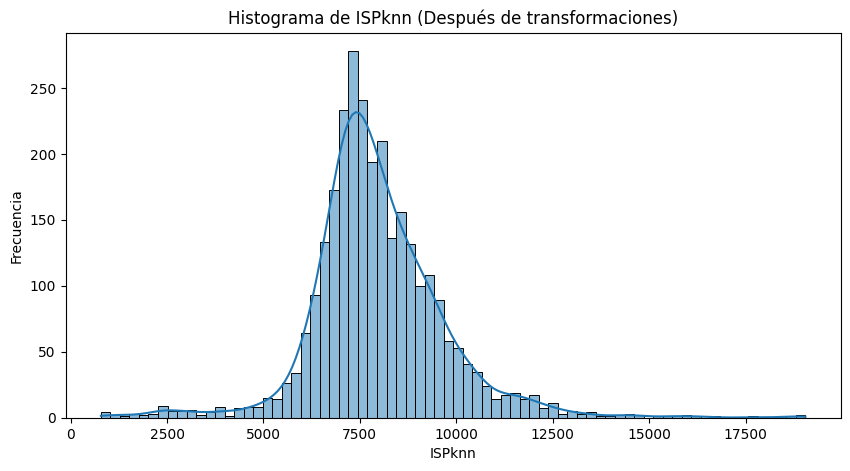

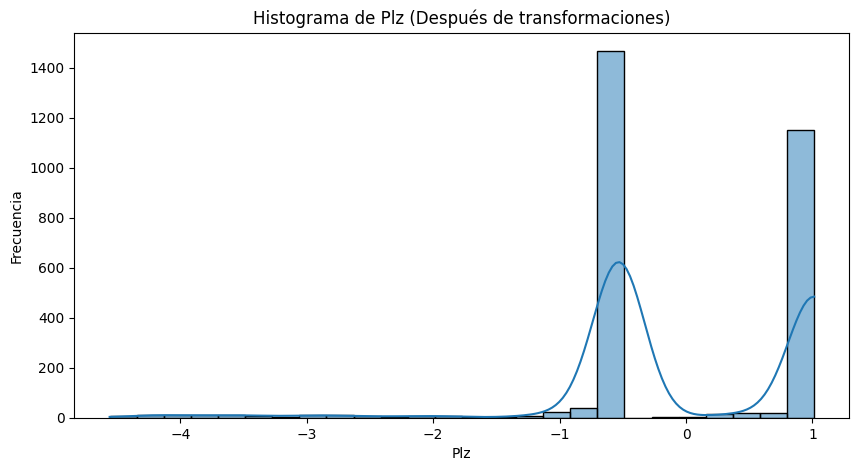

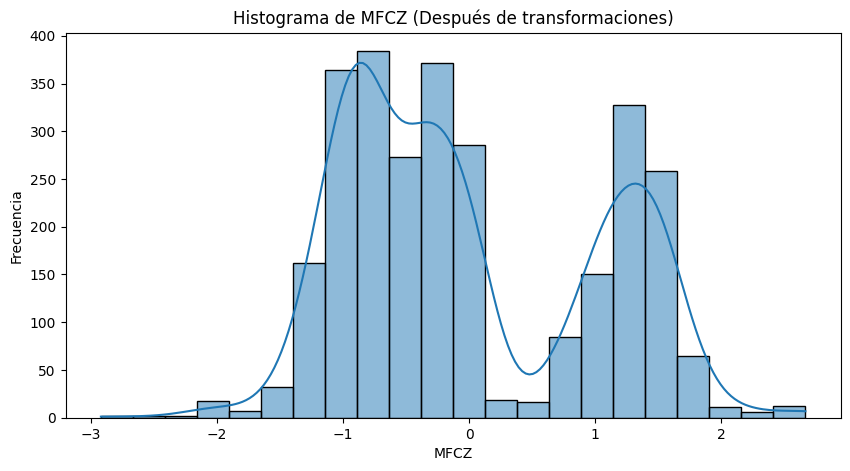

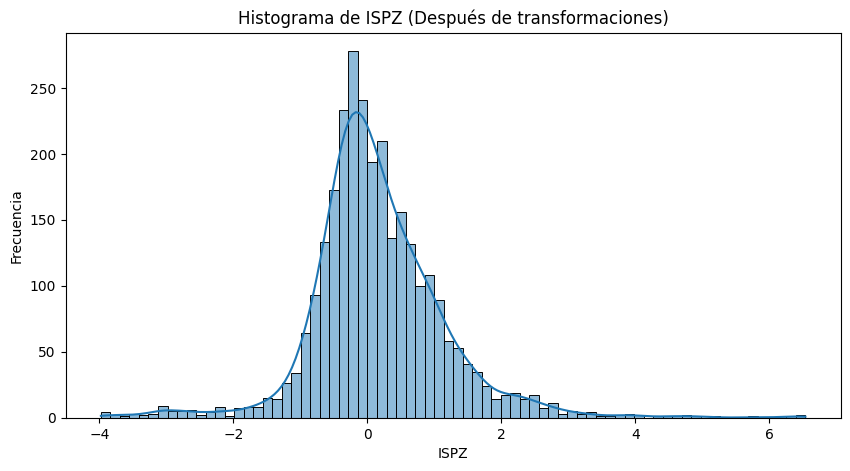

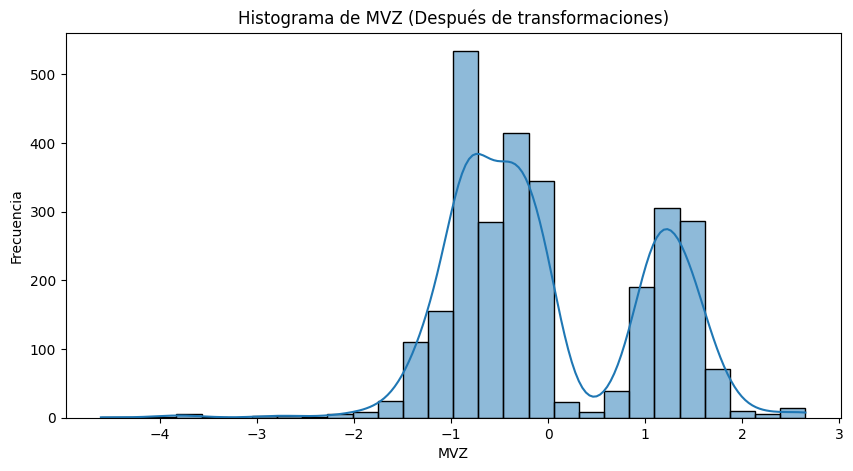

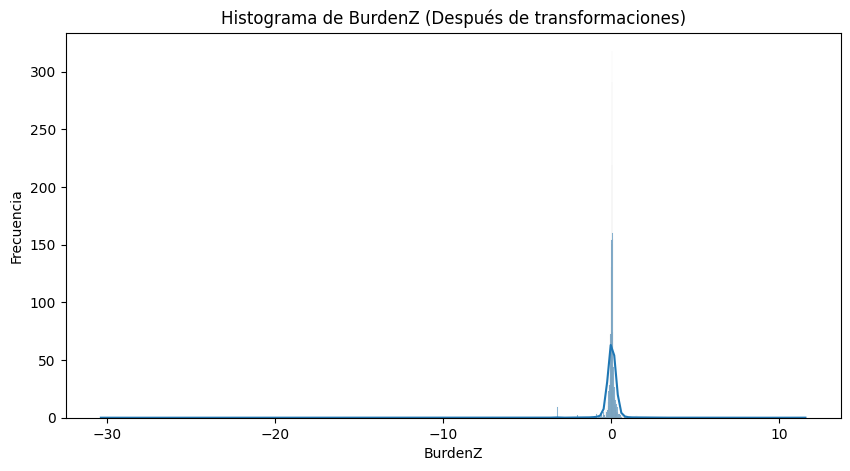

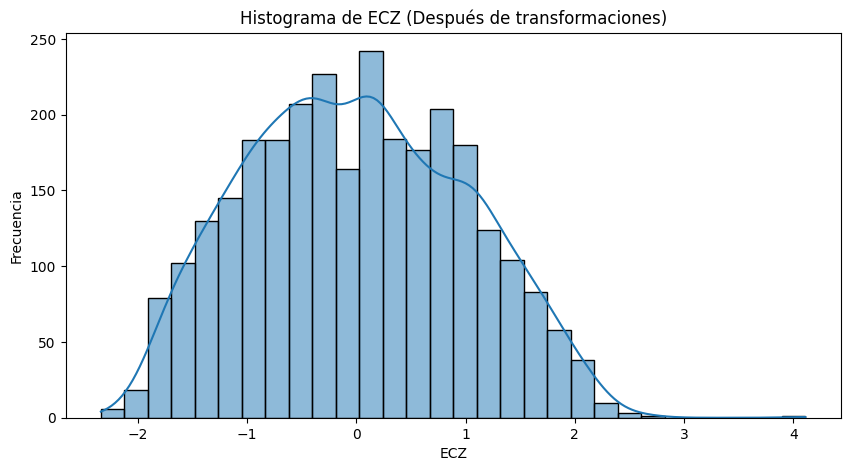

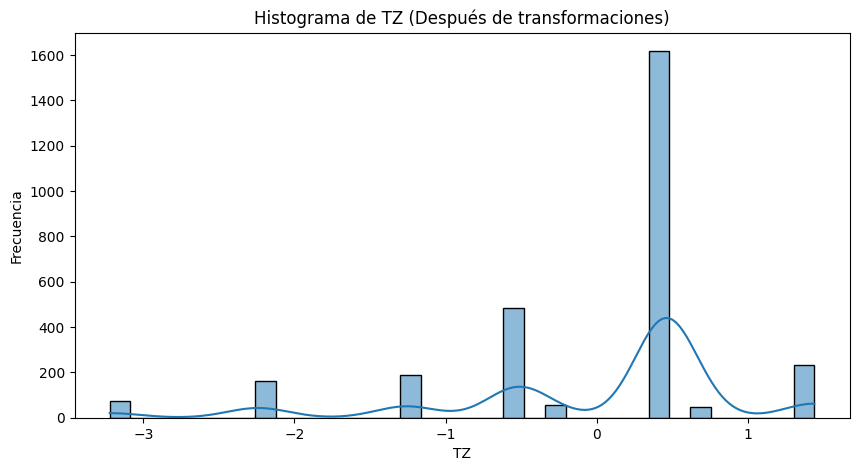

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas actuales
numerical_cols_current = df.select_dtypes(include=['float64', 'int64']).columns

print("Generando histogramas para las columnas numéricas actuales...")
# Crear histogramas para cada columna numérica actual
for col in numerical_cols_current:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Histograma de {col} (Después de transformaciones)')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

Generando diagramas de caja (box plots) para las columnas numéricas actuales...


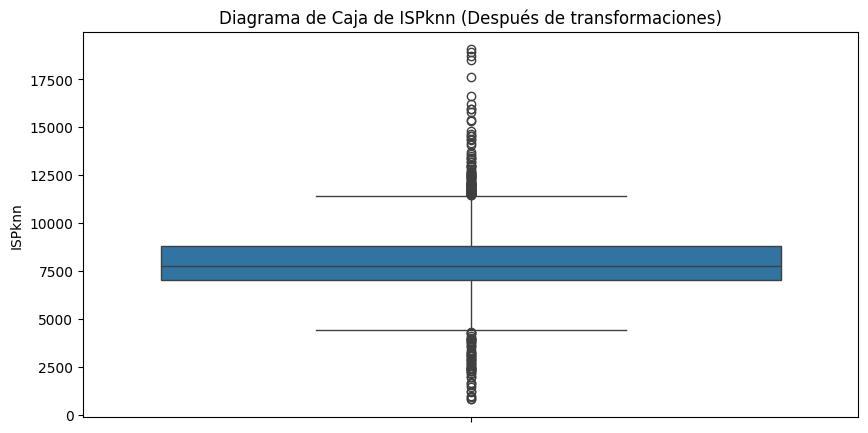

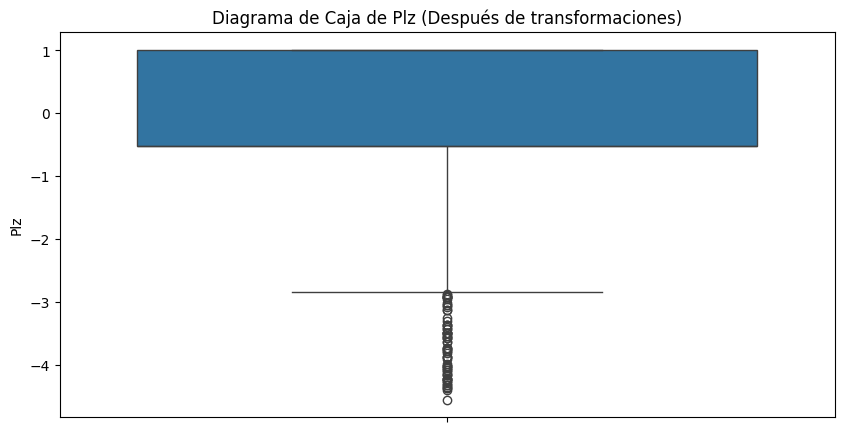

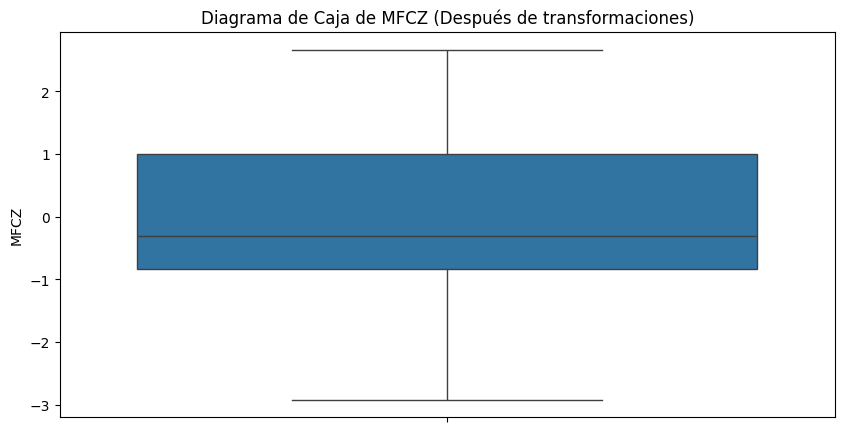

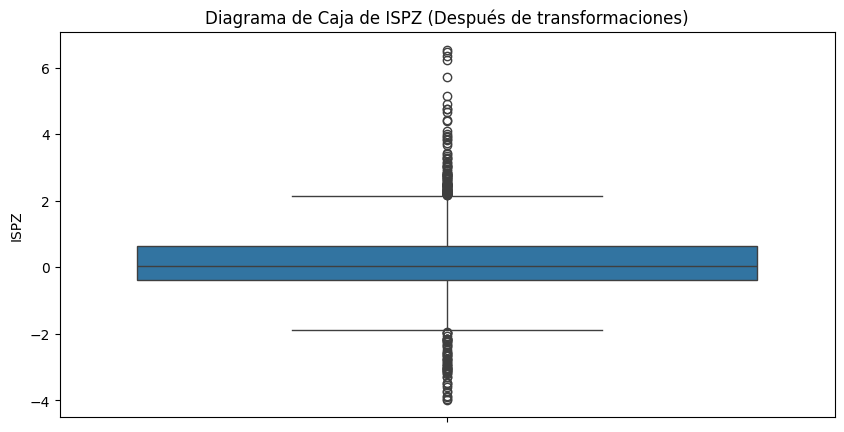

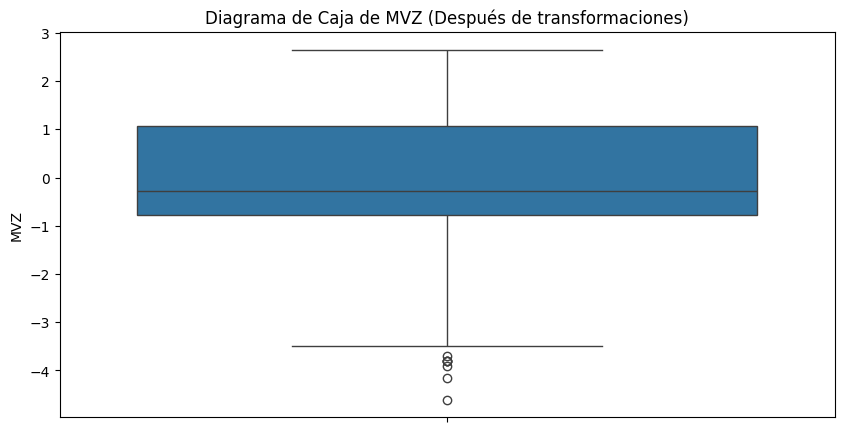

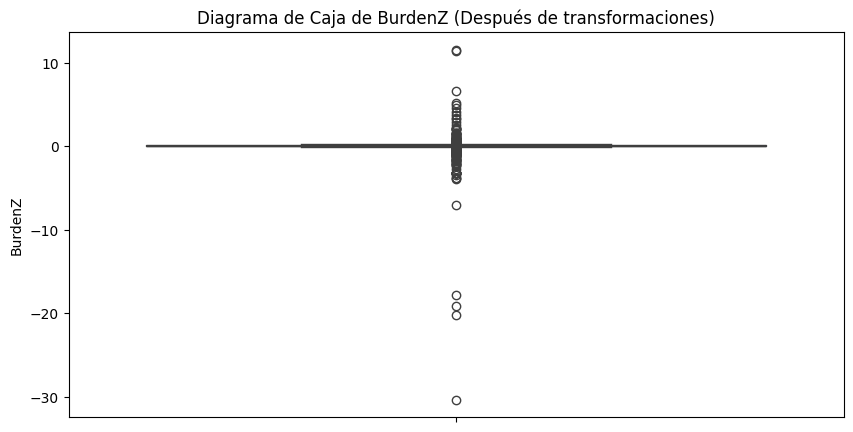

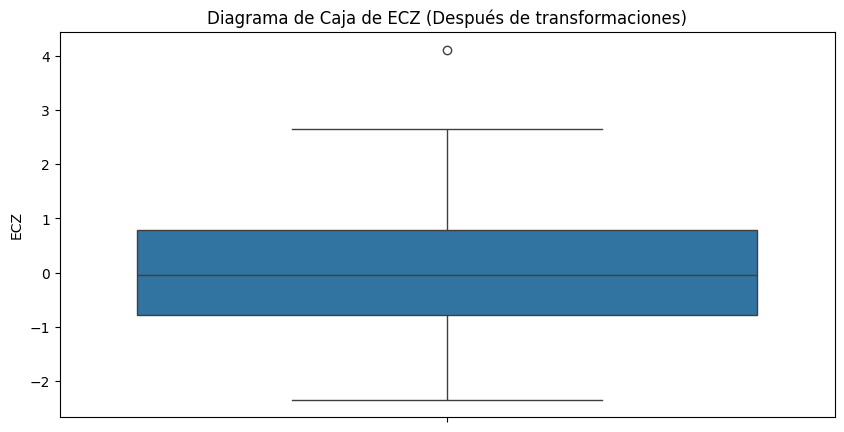

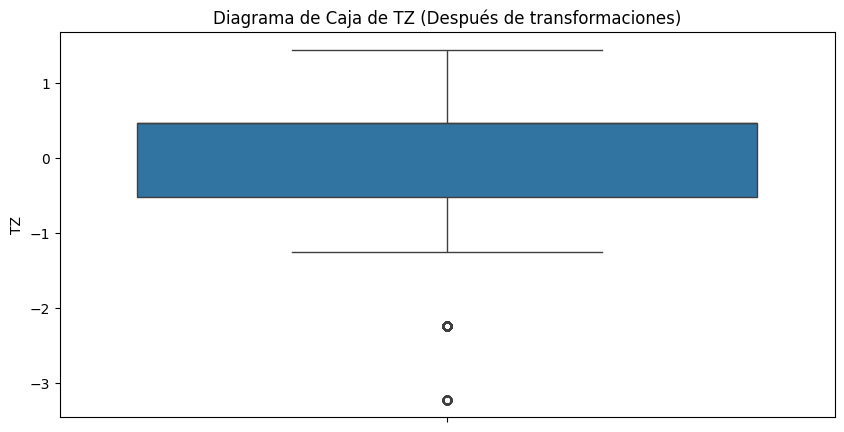

In [ ]:
print("Generando diagramas de caja (box plots) para las columnas numéricas actuales...")
# Crear diagramas de caja (box plots) para cada columna numérica actual
for col in numerical_cols_current:
    plt.figure(figsize=(10, 5))
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Diagrama de Caja de {col} (Después de transformaciones)')
    plt.ylabel(col)
    plt.show()

In [ ]:
display(df.head())

,SC,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,ISPknn,Plz,MFCZ,ISPZ,MVZ,BurdenZ,ECZ,TZ
0,ACTIVO,NO EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55060,2025,7768.225619,1.013465,2.667896,0.041599,2.651384,1.488050,1.301948,0.456661
1,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,7100,2025,7768.225619,1.013465,2.667896,0.041599,2.651384,1.488050,2.134435,0.456661
2,ACTIVO,NO EXITOSO,2024-08-02,2028-07-28,CDMX Y AREA METROPOLITANA,EV,UBER,9208,2025,8357.681667,1.013465,2.667896,0.380964,2.651384,0.194868,0.053216,0.456661
3,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,52916,2025,8154.263333,1.013465,2.667896,0.263851,2.651384,0.265228,-0.258967,0.456661
4,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55749,2025,7984.343333,1.013465,2.667896,0.166024,2.651384,0.400091,0.989765,0.456661


In [ ]:
# Drop the 'ISPknn' column
df = df.drop(columns=['ISPknn'], errors='ignore')

print("Columna 'ISPknn' eliminada correctamente.")
print("--------------------------------------------------")

# Display unique values of the 'SC' column
print("Valores únicos en la columna 'SC':")
print(df['SC'].unique())

Columna 'ISPknn' eliminada correctamente.
--------------------------------------------------
Valores únicos en la columna 'SC':
['ACTIVO' 'REESTRUCTURADO' 'QUEBRANTADO' 'CANCELADO' 'TERMINADO']


In [ ]:
count_cancelado = df[df['SC'] == 'CANCELADO'].shape[0]
print(f"Número de filas con SC 'CANCELADO': {count_cancelado}")

Número de filas con SC 'CANCELADO': 9


In [ ]:
# Drop rows where 'SC' is 'CANCELADO'
df = df[df['SC'] != 'CANCELADO']

print("Filas con SC 'CANCELADO' eliminadas correctamente.")
print("--------------------------------------------------")

# Display unique values of the 'SC' column after dropping
print("Valores únicos en la columna 'SC' después de la eliminación:")
print(df['SC'].unique())

Filas con SC 'CANCELADO' eliminadas correctamente.
--------------------------------------------------
Valores únicos en la columna 'SC' después de la eliminación:
['ACTIVO' 'REESTRUCTURADO' 'QUEBRANTADO' 'TERMINADO']


In [ ]:
import numpy as np

# Columns to check for outliers
outlier_cols = ['ISPZ', 'MVZ', 'BurdenZ', 'ECZ', 'TZ']

print("--------------------------------------------------")
print("Conteo de Outliers por Columna (Método IQR):")
print("--------------------------------------------------")

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    print(f"Columna '{col}': {num_outliers} outliers")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límite Inferior: {lower_bound:.2f}, Límite Superior: {upper_bound:.2f}")
    print("--------------------------------------------------")


--------------------------------------------------
Conteo de Outliers por Columna (Método IQR):
--------------------------------------------------
Columna 'ISPZ': 158 outliers
  Q1: -0.38, Q3: 0.63, IQR: 1.01
  Límite Inferior: -1.90, Límite Superior: 2.16
--------------------------------------------------
Columna 'MVZ': 8 outliers
  Q1: -0.78, Q3: 1.08, IQR: 1.86
  Límite Inferior: -3.57, Límite Superior: 3.87
--------------------------------------------------
Columna 'BurdenZ': 391 outliers
  Q1: -0.02, Q3: 0.08, IQR: 0.10
  Límite Inferior: -0.17, Límite Superior: 0.23
--------------------------------------------------
Columna 'ECZ': 1 outliers
  Q1: -0.78, Q3: 0.78, IQR: 1.56
  Límite Inferior: -3.12, Límite Superior: 3.12
--------------------------------------------------
Columna 'TZ': 232 outliers
  Q1: -0.52, Q3: 0.46, IQR: 0.98
  Límite Inferior: -2.00, Límite Superior: 1.93
--------------------------------------------------


In [ ]:
# Calculate IQR for MVZ to identify outliers
Q1_mvz = df['MVZ'].quantile(0.25)
Q3_mvz = df['MVZ'].quantile(0.75)
IQR_mvz = Q3_mvz - Q1_mvz

lower_bound_mvz = Q1_mvz - 1.5 * IQR_mvz
upper_bound_mvz = Q3_mvz + 1.5 * IQR_mvz

# Filter out the outliers in MVZ
df_filtered = df[(df['MVZ'] >= lower_bound_mvz) & (df['MVZ'] <= upper_bound_mvz)].copy()

num_removed_mvz = df.shape[0] - df_filtered.shape[0]
print(f"Número de filas eliminadas (outliers en MVZ): {num_removed_mvz}")
print(f"Nuevo tamaño del DataFrame: {df_filtered.shape[0]} filas")

# Update the main df to the filtered one
df = df_filtered.copy()

Número de filas eliminadas (outliers en MVZ): 8
Nuevo tamaño del DataFrame: 2836 filas


In [ ]:
import numpy as np

# Columns to check for outliers again (excluding MVZ as it was already handled)
outlier_cols_recheck = ['ISPZ', 'BurdenZ', 'ECZ', 'TZ']

print("--------------------------------------------------")
print("Conteo de Outliers por Columna (Método IQR) en el DataFrame filtrado:")
print("--------------------------------------------------")

for col in outlier_cols_recheck:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    print(f"Columna '{col}': {num_outliers} outliers")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límite Inferior: {lower_bound:.2f}, Límite Superior: {upper_bound:.2f}")
    print("--------------------------------------------------")

--------------------------------------------------
Conteo de Outliers por Columna (Método IQR) en el DataFrame filtrado:
--------------------------------------------------
Columna 'ISPZ': 158 outliers
  Q1: -0.38, Q3: 0.64, IQR: 1.01
  Límite Inferior: -1.90, Límite Superior: 2.16
--------------------------------------------------
Columna 'BurdenZ': 391 outliers
  Q1: -0.02, Q3: 0.08, IQR: 0.10
  Límite Inferior: -0.17, Límite Superior: 0.23
--------------------------------------------------
Columna 'ECZ': 1 outliers
  Q1: -0.78, Q3: 0.78, IQR: 1.56
  Límite Inferior: -3.12, Límite Superior: 3.12
--------------------------------------------------
Columna 'TZ': 227 outliers
  Q1: -0.52, Q3: 0.46, IQR: 0.98
  Límite Inferior: -2.00, Límite Superior: 1.93
--------------------------------------------------


In [ ]:
from google.colab import files

output_filename = 'M2Orange.csv'
df.to_csv(output_filename, index=False)

print(f"DataFrame guardado como '{output_filename}'")
files.download(output_filename)

DataFrame guardado como 'M2Orange.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Replace 'Uber' with 'UBER' in the 'Pt' column
df['Pt'] = df['Pt'].replace('Uber', 'UBER')

print("--------------------------------------------------")
print("Valores únicos en la columna 'Pt' después de la modificación:")
print(df['Pt'].unique())
print("--------------------------------------------------")

--------------------------------------------------
Valores únicos en la columna 'Pt' después de la modificación:
['UBER' 'DIDI']
--------------------------------------------------


In [ ]:
from google.colab import files

output_filename = 'M2Orange.csv'
df.to_csv(output_filename, index=False)

print(f"DataFrame guardado y listo para descargar como '{output_filename}'")
files.download(output_filename)

DataFrame guardado y listo para descargar como 'M2Orange.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

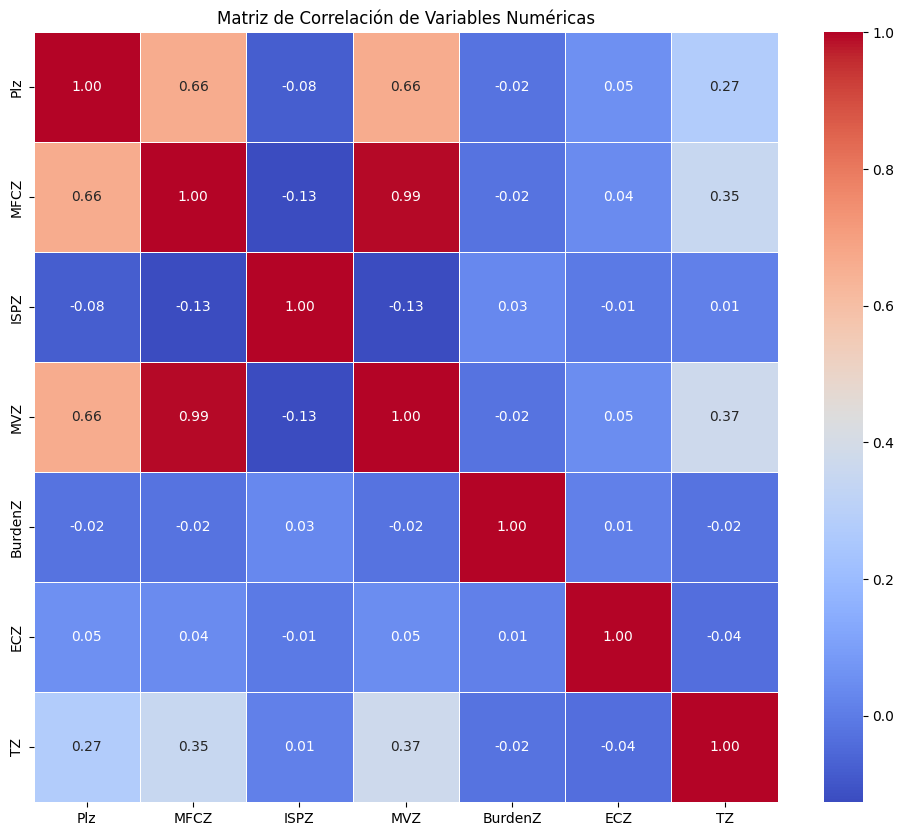

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas del DataFrame actual
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = numerical_df.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

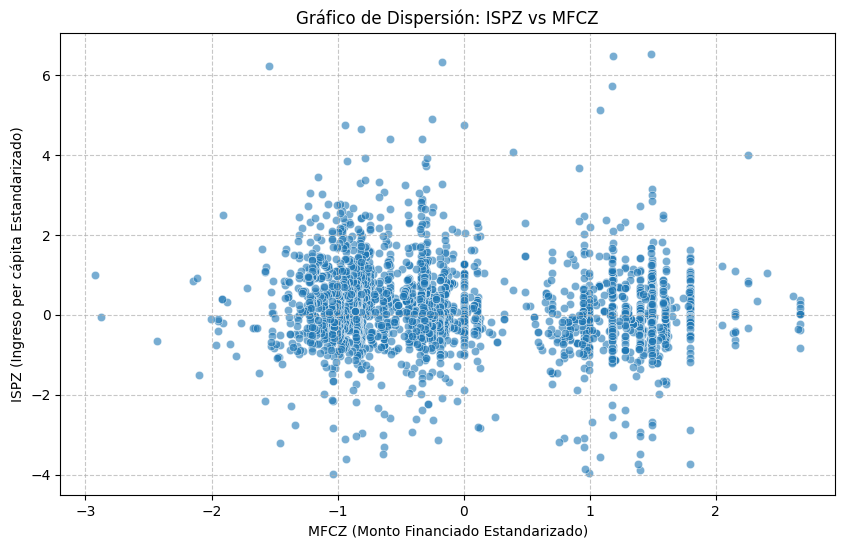

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de dispersión para ISPZ vs MFCZ
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MFCZ', y='ISPZ', data=df, alpha=0.6)
plt.title('Gráfico de Dispersión: ISPZ vs MFCZ')
plt.xlabel('MFCZ (Monto Financiado Estandarizado)')
plt.ylabel('ISPZ (Ingreso per cápita Estandarizado)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

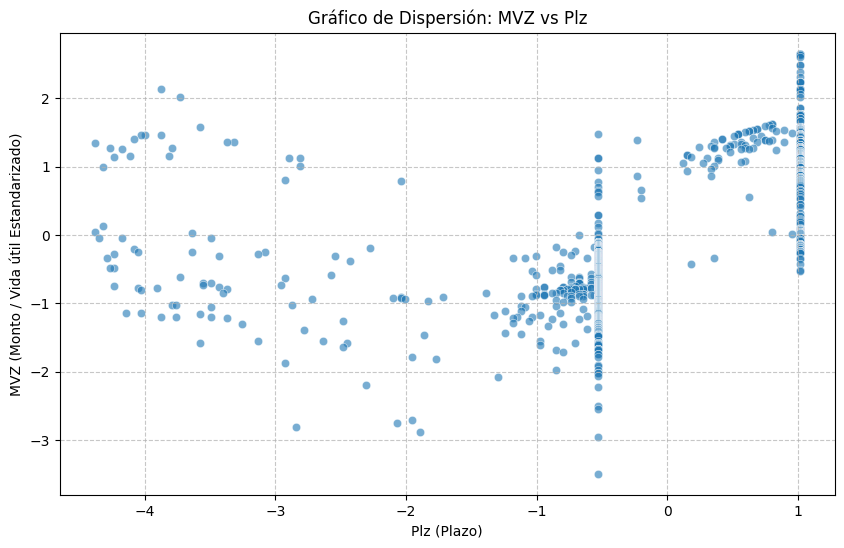

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de dispersión para MVZ vs Plz
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Plz', y='MVZ', data=df, alpha=0.6)
plt.title('Gráfico de Dispersión: MVZ vs Plz')
plt.xlabel('Plz (Plazo)')
plt.ylabel('MVZ (Monto / Vida útil Estandarizado)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

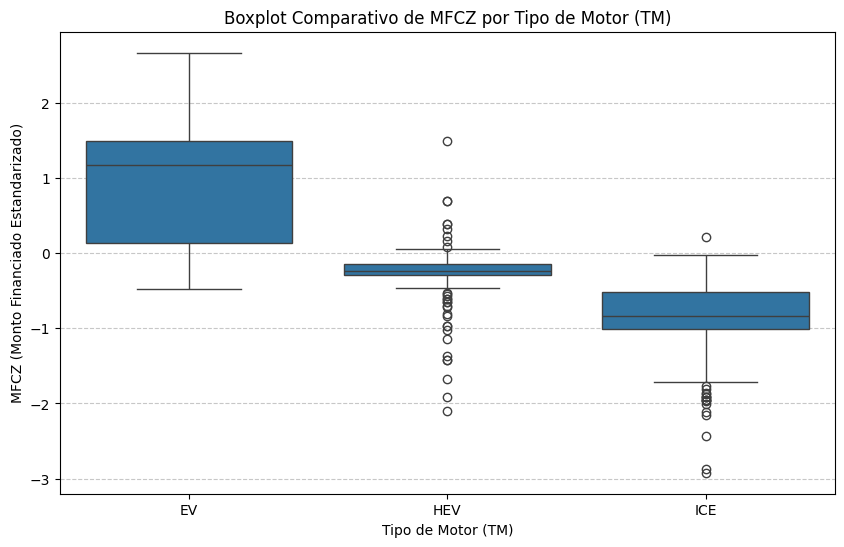

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='TM', y='MFCZ', data=df)
plt.title('Boxplot Comparativo de MFCZ por Tipo de Motor (TM)')
plt.xlabel('Tipo de Motor (TM)')
plt.ylabel('MFCZ (Monto Financiado Estandarizado)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np

# 1. Contar las filas para cada tipo de TM
tm_counts = df['TM'].value_counts()
print("--------------------------------------------------")
print("Conteo de Filas por Tipo de Motor (TM):")
print("--------------------------------------------------")
print(tm_counts)
print("\n")

# 2. Calcular outliers para MFCZ dentro de cada grupo TM
print("--------------------------------------------------")
print("Análisis de Outliers en MFCZ por Tipo de Motor:")
print("--------------------------------------------------")

for tm_type in df['TM'].unique():
    df_tm_group = df[df['TM'] == tm_type]

    Q1_mfc_group = df_tm_group['MFCZ'].quantile(0.25)
    Q3_mfc_group = df_tm_group['MFCZ'].quantile(0.75)
    IQR_mfc_group = Q3_mfc_group - Q1_mfc_group

    lower_bound_mfc_group = Q1_mfc_group - 1.5 * IQR_mfc_group
    upper_bound_mfc_group = Q3_mfc_group + 1.5 * IQR_mfc_group

    # Contar outliers en este grupo
    outliers_mfc_group = df_tm_group[(df_tm_group['MFCZ'] < lower_bound_mfc_group) | (df_tm_group['MFCZ'] > upper_bound_mfc_group)]
    num_outliers_mfc_group = outliers_mfc_group.shape[0]

    # Calcular porcentaje de outliers
    total_in_group = df_tm_group.shape[0]
    percentage_outliers = (num_outliers_mfc_group / total_in_group) * 100 if total_in_group > 0 else 0

    print(f"Tipo de Motor: {tm_type}")
    print(f"  Total de filas en el grupo: {total_in_group}")
    print(f"  Número de outliers en MFCZ: {num_outliers_mfc_group}")
    print(f"  Porcentaje de outliers en MFCZ: {percentage_outliers:.2f}%")
    print("--------------------------------------------------")

--------------------------------------------------
Conteo de Filas por Tipo de Motor (TM):
--------------------------------------------------
TM
ICE    1455
EV     1242
HEV     139
Name: count, dtype: int64


--------------------------------------------------
Análisis de Outliers en MFCZ por Tipo de Motor:
--------------------------------------------------
Tipo de Motor: EV
  Total de filas en el grupo: 1242
  Número de outliers en MFCZ: 0
  Porcentaje de outliers en MFCZ: 0.00%
--------------------------------------------------
Tipo de Motor: HEV
  Total de filas en el grupo: 139
  Número de outliers en MFCZ: 30
  Porcentaje de outliers en MFCZ: 21.58%
--------------------------------------------------
Tipo de Motor: ICE
  Total de filas en el grupo: 1455
  Número de outliers en MFCZ: 18
  Porcentaje de outliers en MFCZ: 1.24%
--------------------------------------------------


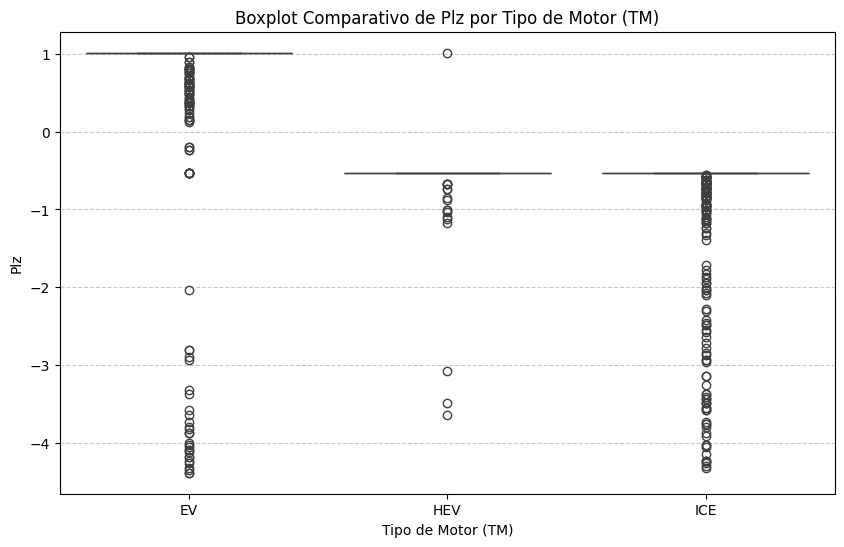

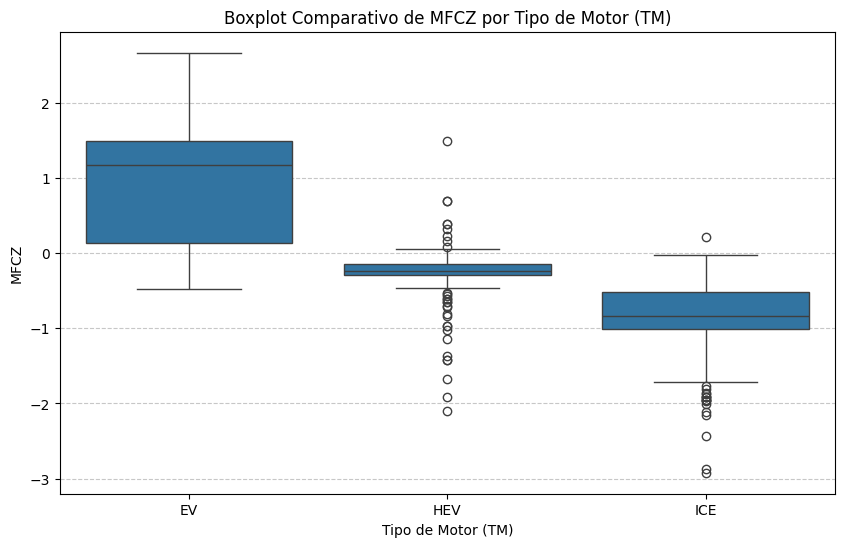

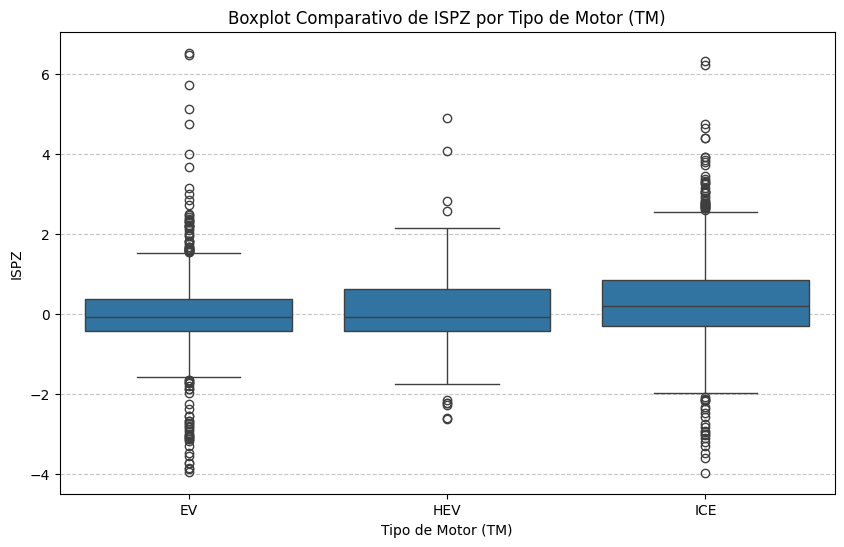

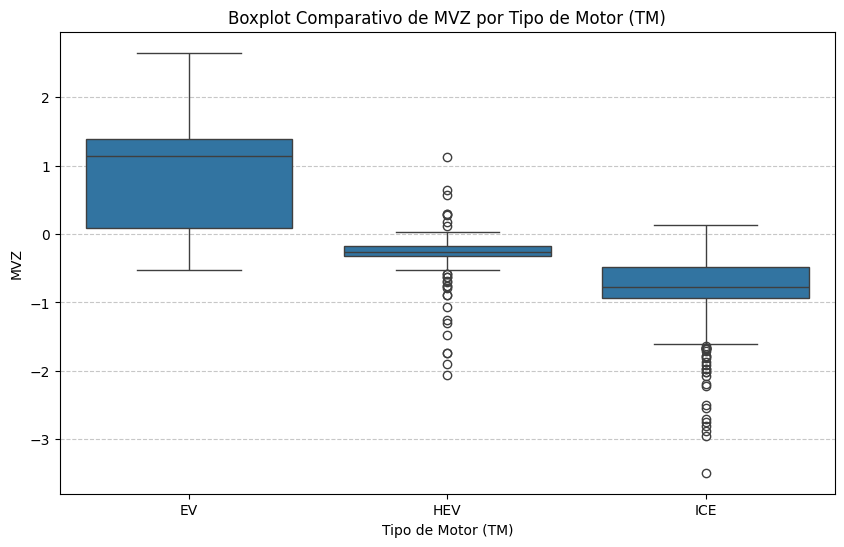

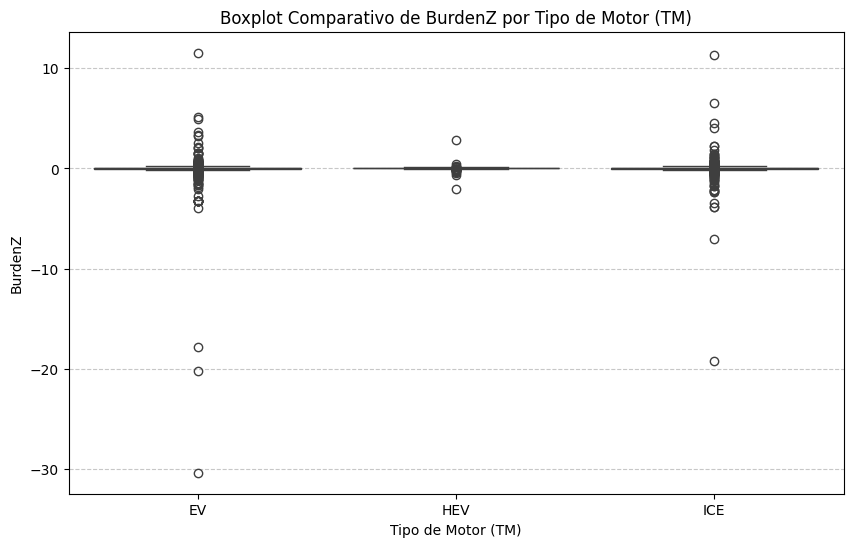

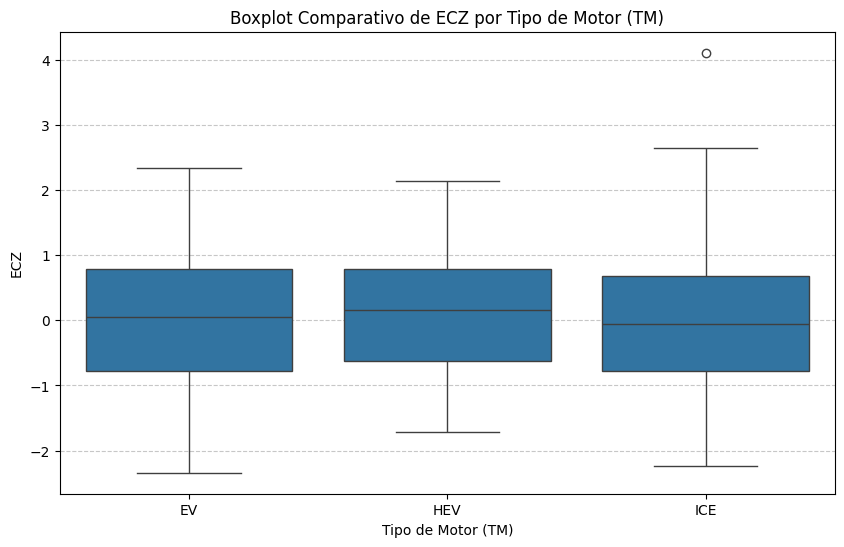

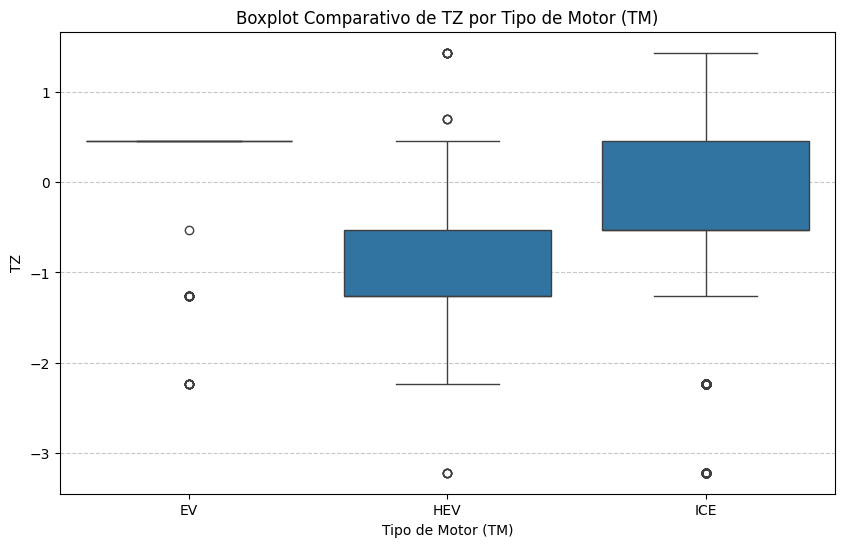

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas (excluyendo FIn y Fter que son datetime)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Iterar sobre cada columna numérica para crear un boxplot comparativo por TM
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='TM', y=col, data=df)
    plt.title(f'Boxplot Comparativo de {col} por Tipo de Motor (TM)')
    plt.xlabel('Tipo de Motor (TM)')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [ ]:
import numpy as np

outlier_cols_percentage = ['ISPZ', 'BurdenZ', 'ECZ', 'TZ']
total_records = df.shape[0]

print("--------------------------------------------------")
print("Porcentaje de Outliers por Columna (Método IQR):")
print("--------------------------------------------------")

for col in outlier_cols_percentage:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Calculate percentage
    percentage = (num_outliers / total_records) * 100 if total_records > 0 else 0

    print(f"Columna '{col}':")
    print(f"  Número de outliers: {num_outliers}")
    print(f"  Porcentaje de outliers: {percentage:.2f}%")
    print("--------------------------------------------------")

--------------------------------------------------
Porcentaje de Outliers por Columna (Método IQR):
--------------------------------------------------
Columna 'ISPZ':
  Número de outliers: 158
  Porcentaje de outliers: 5.57%
--------------------------------------------------
Columna 'BurdenZ':
  Número de outliers: 391
  Porcentaje de outliers: 13.79%
--------------------------------------------------
Columna 'ECZ':
  Número de outliers: 1
  Porcentaje de outliers: 0.04%
--------------------------------------------------
Columna 'TZ':
  Número de outliers: 227
  Porcentaje de outliers: 8.00%
--------------------------------------------------


In [ ]:
import numpy as np

# Calculate IQR for ECZ to identify outliers
Q1_ecz = df['ECZ'].quantile(0.25)
Q3_ecz = df['ECZ'].quantile(0.75)
IQR_ecz = Q3_ecz - Q1_ecz

lower_bound_ecz = Q1_ecz - 1.5 * IQR_ecz
upper_bound_ecz = Q3_ecz + 1.5 * IQR_ecz

# Filter out the outliers in ECZ
df_filtered_ecz = df[(df['ECZ'] >= lower_bound_ecz) & (df['ECZ'] <= upper_bound_ecz)].copy()

num_removed_ecz = df.shape[0] - df_filtered_ecz.shape[0]
print(f"Número de filas eliminadas (outliers en ECZ): {num_removed_ecz}")
print(f"Nuevo tamaño del DataFrame: {df_filtered_ecz.shape[0]} filas")

# Update the main df to the filtered one
df = df_filtered_ecz.copy()

Número de filas eliminadas (outliers en ECZ): 1
Nuevo tamaño del DataFrame: 2835 filas


In [ ]:
import numpy as np

outlier_cols_percentage_recheck = ['ISPZ', 'BurdenZ', 'ECZ', 'TZ']
total_records_new = df.shape[0]

print("\n--------------------------------------------------")
print("Porcentaje de Outliers por Columna (Método IQR) después de eliminar outliers de ECZ:")
print("--------------------------------------------------")

for col in outlier_cols_percentage_recheck:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Calculate percentage
    percentage = (num_outliers / total_records_new) * 100 if total_records_new > 0 else 0

    print(f"Columna '{col}':")
    print(f"  Número de outliers: {num_outliers}")
    print(f"  Porcentaje de outliers: {percentage:.2f}%")
    print("--------------------------------------------------")


--------------------------------------------------
Porcentaje de Outliers por Columna (Método IQR) después de eliminar outliers de ECZ:
--------------------------------------------------
Columna 'ISPZ':
  Número de outliers: 158
  Porcentaje de outliers: 5.57%
--------------------------------------------------
Columna 'BurdenZ':
  Número de outliers: 391
  Porcentaje de outliers: 13.79%
--------------------------------------------------
Columna 'ECZ':
  Número de outliers: 0
  Porcentaje de outliers: 0.00%
--------------------------------------------------
Columna 'TZ':
  Número de outliers: 227
  Porcentaje de outliers: 8.01%
--------------------------------------------------


In [ ]:
# Generar la nueva columna BurZ
df['BurZ'] = (df['MFCZ'] / df['Plz']) - df['ISPZ']

print("Columna 'BurZ' creada exitosamente.")
display(df.head())

Columna 'BurZ' creada exitosamente.


,SC,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,BurdenZ,ECZ,TZ,BurZ
0,ACTIVO,NO EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55060,2025,1.013465,2.667896,0.041599,2.651384,1.488050,1.301948,0.456661,2.590850
1,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,7100,2025,1.013465,2.667896,0.041599,2.651384,1.488050,2.134435,0.456661,2.590850
2,ACTIVO,NO EXITOSO,2024-08-02,2028-07-28,CDMX Y AREA METROPOLITANA,EV,UBER,9208,2025,1.013465,2.667896,0.380964,2.651384,0.194868,0.053216,0.456661,2.251485
3,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,52916,2025,1.013465,2.667896,0.263851,2.651384,0.265228,-0.258967,0.456661,2.368598
4,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55749,2025,1.013465,2.667896,0.166024,2.651384,0.400091,0.989765,0.456661,2.466425


In [ ]:
# Drop the 'BurdenZ' column
df = df.drop(columns=['BurdenZ'], errors='ignore')

print("Columna 'BurdenZ' eliminada correctamente.")
display(df.head())

Columna 'BurdenZ' eliminada correctamente.


,SC,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ
0,ACTIVO,NO EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55060,2025,1.013465,2.667896,0.041599,2.651384,1.301948,0.456661,2.590850
1,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,7100,2025,1.013465,2.667896,0.041599,2.651384,2.134435,0.456661,2.590850
2,ACTIVO,NO EXITOSO,2024-08-02,2028-07-28,CDMX Y AREA METROPOLITANA,EV,UBER,9208,2025,1.013465,2.667896,0.380964,2.651384,0.053216,0.456661,2.251485
3,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,52916,2025,1.013465,2.667896,0.263851,2.651384,-0.258967,0.456661,2.368598
4,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55749,2025,1.013465,2.667896,0.166024,2.651384,0.989765,0.456661,2.466425


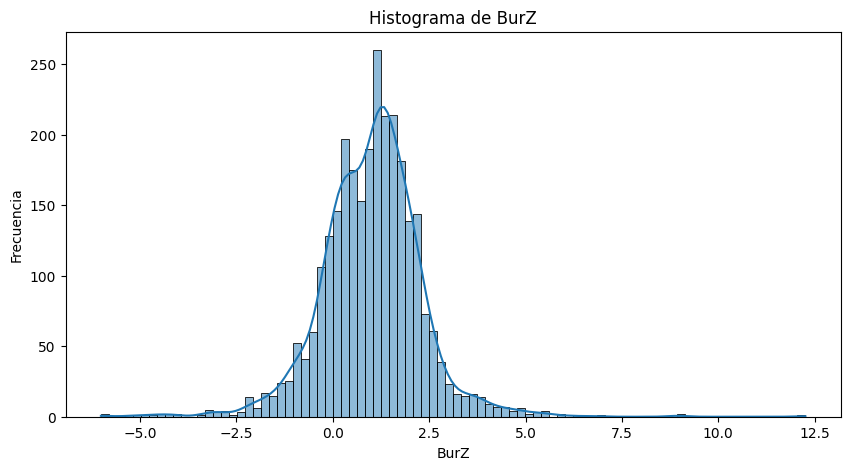

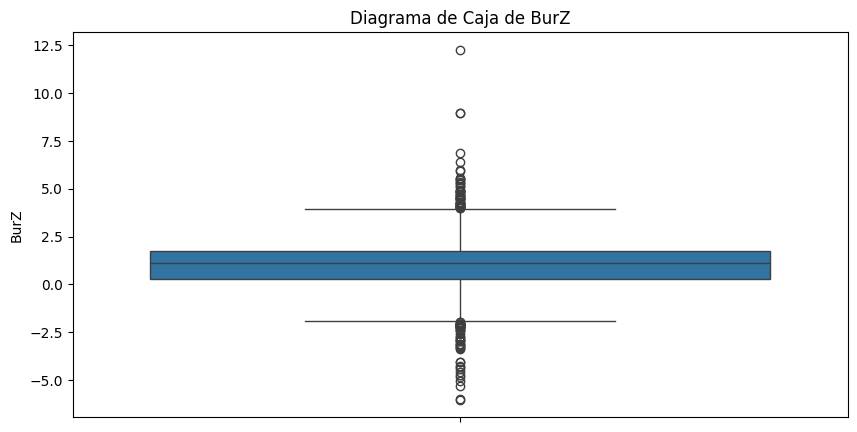

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for BurZ
plt.figure(figsize=(10, 5))
sns.histplot(df['BurZ'].dropna(), kde=True)
plt.title('Histograma de BurZ')
plt.xlabel('BurZ')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot for BurZ
plt.figure(figsize=(10, 5))
sns.boxplot(y=df['BurZ'].dropna())
plt.title('Diagrama de Caja de BurZ')
plt.ylabel('BurZ')
plt.show()

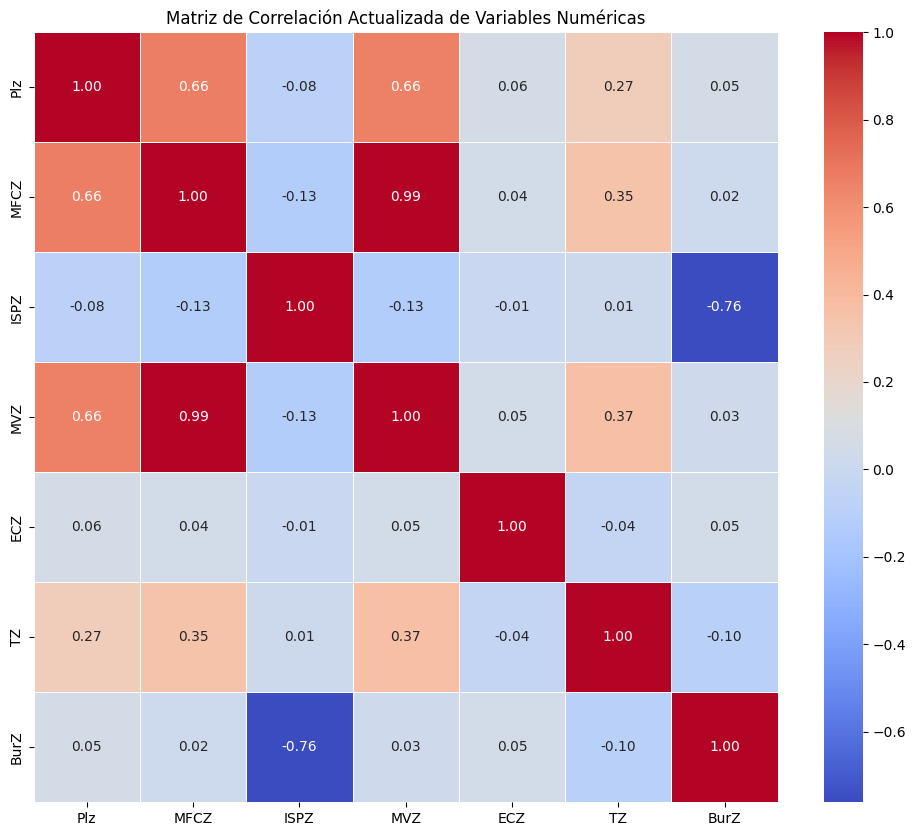

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas del DataFrame actual
numerical_df_updated = df.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix_updated = numerical_df_updated.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_updated, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación Actualizada de Variables Numéricas')
plt.show()

In [ ]:
import numpy as np

# Calculate IQR for BurZ to identify outliers
Q1_burz = df['BurZ'].quantile(0.25)
Q3_burz = df['BurZ'].quantile(0.75)
IQR_burz = Q3_burz - Q1_burz

lower_bound_burz = Q1_burz - 1.5 * IQR_burz
upper_bound_burz = Q3_burz + 1.5 * IQR_burz

# Count outliers in BurZ
outliers_burz = df[(df['BurZ'] < lower_bound_burz) | (df['BurZ'] > upper_bound_burz)]
num_outliers_burz = outliers_burz.shape[0]

total_records = df.shape[0]
percentage_outliers_burz = (num_outliers_burz / total_records) * 100 if total_records > 0 else 0

print("--------------------------------------------------")
print("Porcentaje de Outliers para la columna 'BurZ' (Método IQR):")
print("--------------------------------------------------")
print(f"Columna 'BurZ':")
print(f"  Número de outliers: {num_outliers_burz}")
print(f"  Porcentaje de outliers: {percentage_outliers_burz:.2f}%")
print("--------------------------------------------------")

--------------------------------------------------
Porcentaje de Outliers para la columna 'BurZ' (Método IQR):
--------------------------------------------------
Columna 'BurZ':
  Número de outliers: 96
  Porcentaje de outliers: 3.39%
--------------------------------------------------


In [ ]:
import numpy as np

outlier_cols_all = ['ISPZ', 'ECZ', 'TZ', 'BurZ']
total_records_final = df.shape[0]

print("--------------------------------------------------")
print("Porcentaje de Outliers por Columna (Método IQR) para todas las variables relevantes:")
print("--------------------------------------------------")

for col in outlier_cols_all:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Calculate percentage
    percentage = (num_outliers / total_records_final) * 100 if total_records_final > 0 else 0

    print(f"Columna '{col}':")
    print(f"  Número de outliers: {num_outliers}")
    print(f"  Porcentaje de outliers: {percentage:.2f}%")
    print("--------------------------------------------------")

--------------------------------------------------
Porcentaje de Outliers por Columna (Método IQR) para todas las variables relevantes:
--------------------------------------------------
Columna 'ISPZ':
  Número de outliers: 158
  Porcentaje de outliers: 5.57%
--------------------------------------------------
Columna 'ECZ':
  Número de outliers: 0
  Porcentaje de outliers: 0.00%
--------------------------------------------------
Columna 'TZ':
  Número de outliers: 227
  Porcentaje de outliers: 8.01%
--------------------------------------------------
Columna 'BurZ':
  Número de outliers: 96
  Porcentaje de outliers: 3.39%
--------------------------------------------------


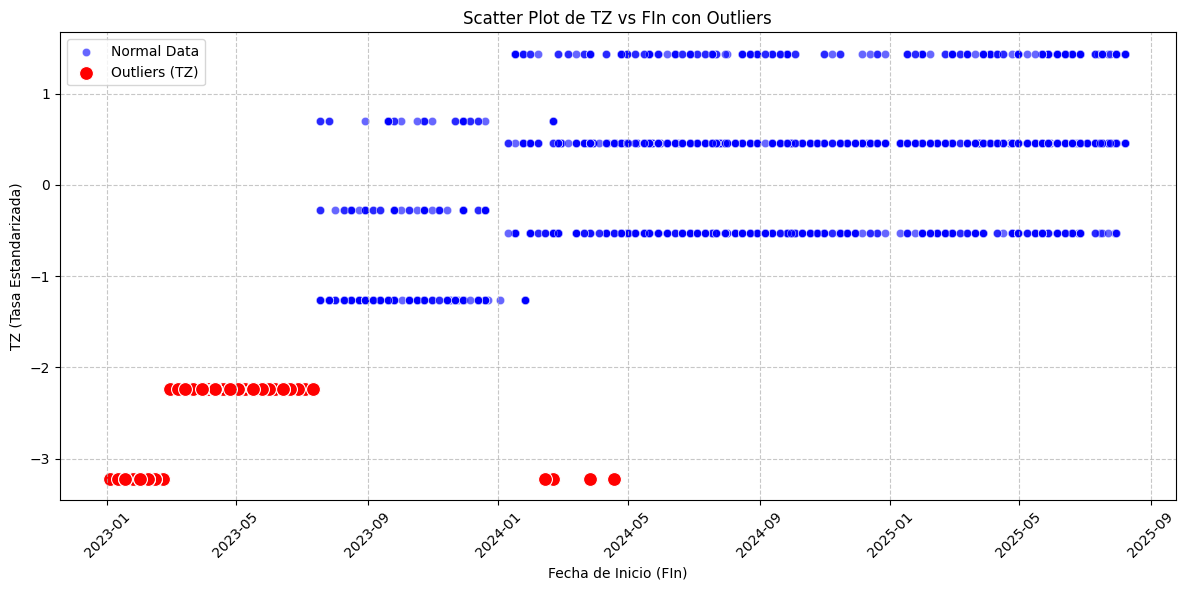

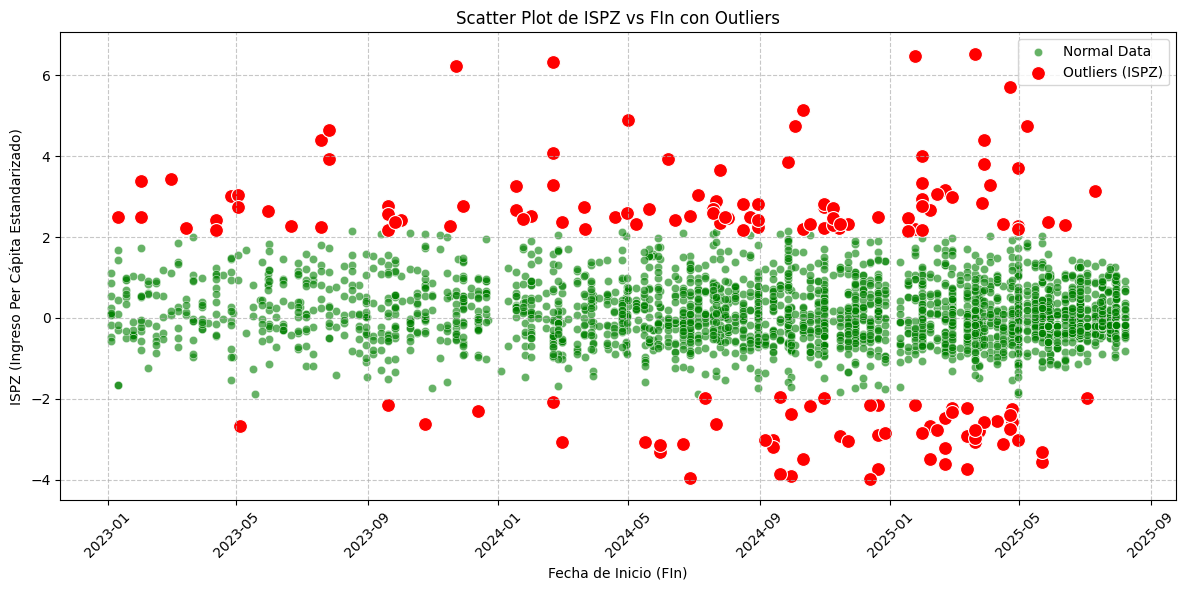

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Plotting outliers for TZ vs FIn ---
# Calculate IQR for TZ
Q1_tz = df['TZ'].quantile(0.25)
Q3_tz = df['TZ'].quantile(0.75)
IQR_tz = Q3_tz - Q1_tz

lower_bound_tz = Q1_tz - 1.5 * IQR_tz
upper_bound_tz = Q3_tz + 1.5 * IQR_tz

# Identify outliers for TZ
outliers_tz = df[(df['TZ'] < lower_bound_tz) | (df['TZ'] > upper_bound_tz)]

plt.figure(figsize=(12, 6))
sns.scatterplot(x='FIn', y='TZ', data=df, color='blue', alpha=0.6, label='Normal Data')
sns.scatterplot(x='FIn', y='TZ', data=outliers_tz, color='red', s=100, label='Outliers (TZ)')
plt.title('Scatter Plot de TZ vs FIn con Outliers')
plt.xlabel('Fecha de Inicio (FIn)')
plt.ylabel('TZ (Tasa Estandarizada)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plotting outliers for ISPZ vs FIn ---
# Calculate IQR for ISPZ
Q1_ispz = df['ISPZ'].quantile(0.25)
Q3_ispz = df['ISPZ'].quantile(0.75)
IQR_ispz = Q3_ispz - Q1_ispz

lower_bound_ispz = Q1_ispz - 1.5 * IQR_ispz
upper_bound_ispz = Q3_ispz + 1.5 * IQR_ispz

# Identify outliers for ISPZ
outliers_ispz = df[(df['ISPZ'] < lower_bound_ispz) | (df['ISPZ'] > upper_bound_ispz)]

plt.figure(figsize=(12, 6))
sns.scatterplot(x='FIn', y='ISPZ', data=df, color='green', alpha=0.6, label='Normal Data')
sns.scatterplot(x='FIn', y='ISPZ', data=outliers_ispz, color='red', s=100, label='Outliers (ISPZ)')
plt.title('Scatter Plot de ISPZ vs FIn con Outliers')
plt.xlabel('Fecha de Inicio (FIn)')
plt.ylabel('ISPZ (Ingreso Per Cápita Estandarizado)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

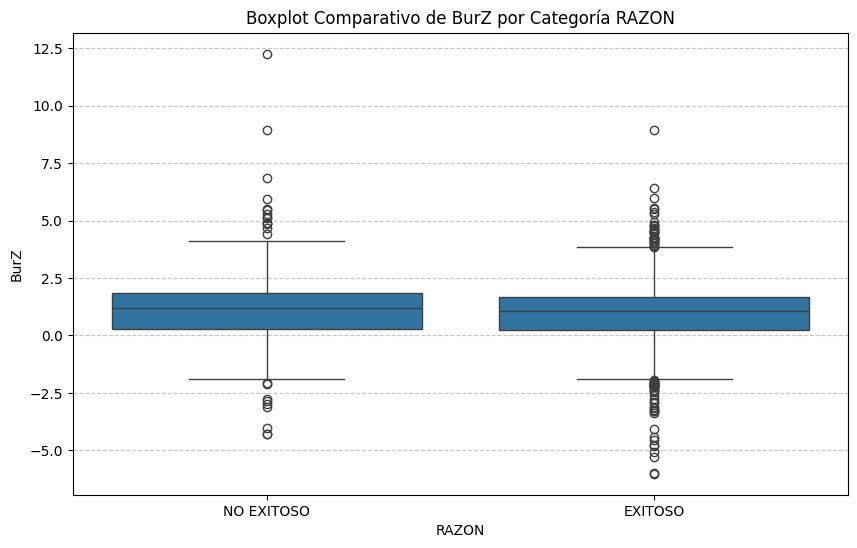

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='RAZON', y='BurZ', data=df)
plt.title('Boxplot Comparativo de BurZ por Categoría RAZON')
plt.xlabel('RAZON')
plt.ylabel('BurZ')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Ensure 'FIn' is in datetime format
df['FIn'] = pd.to_datetime(df['FIn'])

# Filter DataFrame for the year 2023
df_2023 = df[df['FIn'].dt.year == 2023].copy()

print(f"Número de registros en 2023: {df_2023.shape[0]}")

if df_2023.empty:
    print("No hay datos para el año 2023.")
else:
    outlier_cols_2023 = ['ISPZ', 'ECZ', 'TZ', 'BurZ']
    total_records_2023 = df_2023.shape[0]

    print("\n--------------------------------------------------")
    print("Porcentaje de Outliers por Columna (Método IQR) para el año 2023:")
    print("--------------------------------------------------")

    for col in outlier_cols_2023:
        Q1 = df_2023[col].quantile(0.25)
        Q3 = df_2023[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers = df_2023[(df_2023[col] < lower_bound) | (df_2023[col] > upper_bound)]
        num_outliers = outliers.shape[0]

        # Calculate percentage
        percentage = (num_outliers / total_records_2023) * 100 if total_records_2023 > 0 else 0

        print(f"Columna '{col}':")
        print(f"  Número de outliers: {num_outliers}")
        print(f"  Porcentaje de outliers: {percentage:.2f}%")
        print("--------------------------------------------------")

Número de registros en 2023: 490

--------------------------------------------------
Porcentaje de Outliers por Columna (Método IQR) para el año 2023:
--------------------------------------------------
Columna 'ISPZ':
  Número de outliers: 14
  Porcentaje de outliers: 2.86%
--------------------------------------------------
Columna 'ECZ':
  Número de outliers: 0
  Porcentaje de outliers: 0.00%
--------------------------------------------------
Columna 'TZ':
  Número de outliers: 43
  Porcentaje de outliers: 8.78%
--------------------------------------------------
Columna 'BurZ':
  Número de outliers: 10
  Porcentaje de outliers: 2.04%
--------------------------------------------------


In [ ]:
from google.colab import files

output_filename_m2_1 = 'M2.1.csv'
df.to_csv(output_filename_m2_1, index=False)

print(f"DataFrame guardado como '{output_filename_m2_1}'")
files.download(output_filename_m2_1)

DataFrame guardado como 'M2.1.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Identify categorical columns (object and category dtypes)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Columnas categóricas identificadas para One-Hot Encoding: {list(categorical_cols)}")

# Apply One-Hot Encoding, dropping the first category to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("--------------------------------------------------")
print("Dimensiones del DataFrame después del One-Hot Encoding:")
print(df_encoded.shape)

print("--------------------------------------------------")
print("Primeras 5 filas del DataFrame codificado:")
display(df_encoded.head())

print("--------------------------------------------------")
print("Información del DataFrame codificado:")
print(df_encoded.info())

Columnas categóricas identificadas para One-Hot Encoding: ['SC', 'RAZON', 'ZC', 'TM', 'Pt', 'CP', 'Md']
--------------------------------------------------
Dimensiones del DataFrame después del One-Hot Encoding:
(2835, 1298)
--------------------------------------------------
Primeras 5 filas del DataFrame codificado:


,FIn,Fter,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ,SC_QUEBRANTADO,...,CP_76904,CP_76915,CP_76925,Md_2020,Md_2021,Md_2022,Md_2023,Md_2024,Md_2025,Md_2026
0,2024-07-31,2028-07-26,1.013465,2.667896,0.041599,2.651384,1.301948,0.456661,2.590850,False,...,False,False,False,False,False,False,False,False,True,False
1,2024-07-31,2028-07-26,1.013465,2.667896,0.041599,2.651384,2.134435,0.456661,2.590850,False,...,False,False,False,False,False,False,False,False,True,False
2,2024-08-02,2028-07-28,1.013465,2.667896,0.380964,2.651384,0.053216,0.456661,2.251485,False,...,False,False,False,False,False,False,False,False,True,False
3,2024-07-31,2028-07-26,1.013465,2.667896,0.263851,2.651384,-0.258967,0.456661,2.368598,False,...,False,False,False,False,False,False,False,False,True,False
4,2024-07-31,2028-07-26,1.013465,2.667896,0.166024,2.651384,0.989765,0.456661,2.466425,False,...,False,False,False,False,False,False,False,False,True,False


--------------------------------------------------
Información del DataFrame codificado:
<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2844
Columns: 1298 entries, FIn to Md_2026
dtypes: bool(1289), datetime64[ns](2), float64(7)
memory usage: 3.7 MB
None


In [ ]:
# Update the main DataFrame to the encoded one
df = df_encoded.copy()

print("DataFrame actualizado con variables codificadas.")

DataFrame actualizado con variables codificadas.


Estadísticas descriptivas de la columna 'Rate_Shock':


,Rate_Shock
count,2835.000000
mean,-0.148480
std,1.398236
min,-7.479093
25%,-0.811212
50%,0.131151
75%,0.735637
max,4.435043


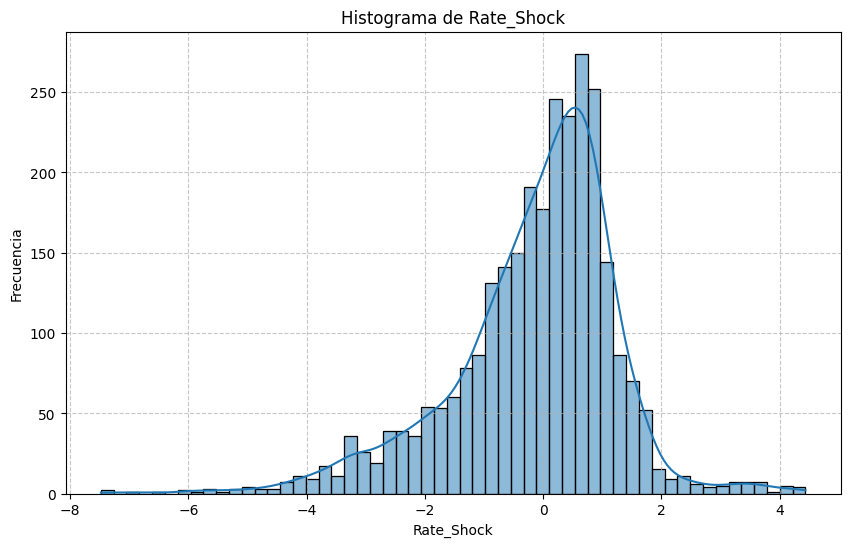

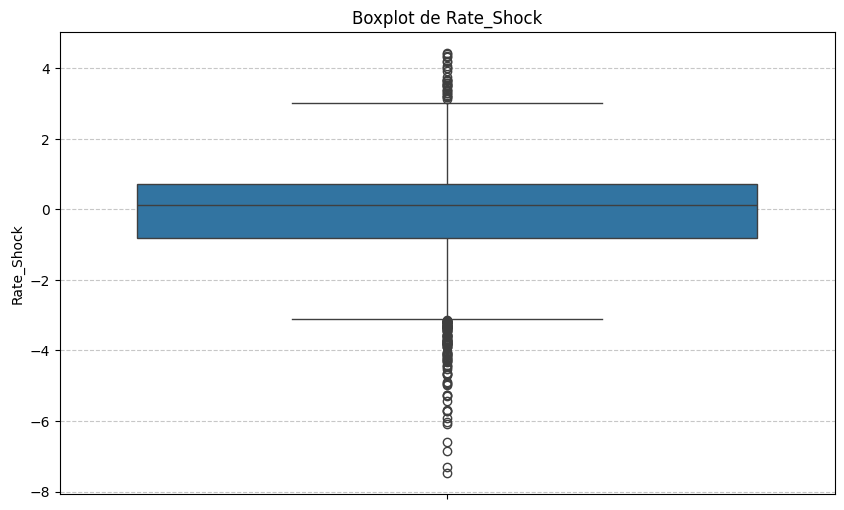

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la columna 'Rate_Shock'
df['Rate_Shock'] = df['TZ'] - df['ISPZ']

# Reemplazar valores infinitos (resultantes de división por cero) con NaN
df['Rate_Shock'].replace([np.inf, -np.inf], np.nan, inplace=False)

print("Estadísticas descriptivas de la columna 'Rate_Shock':")
display(df['Rate_Shock'].describe())

# Histograma de 'Rate_Shock'
plt.figure(figsize=(10, 6))
sns.histplot(df['Rate_Shock'].dropna(), kde=True)
plt.title('Histograma de Rate_Shock')
plt.xlabel('Rate_Shock')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Boxplot de 'Rate_Shock'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Rate_Shock'].dropna())
plt.title('Boxplot de Rate_Shock')
plt.ylabel('Rate_Shock')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from google.colab import files

output_filename_m2_encoder = 'M2encoder.csv'
df.to_csv(output_filename_m2_encoder, index=False)

print(f"DataFrame guardado como '{output_filename_m2_encoder}'")
files.download(output_filename_m2_encoder)

DataFrame guardado como 'M2encoder.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

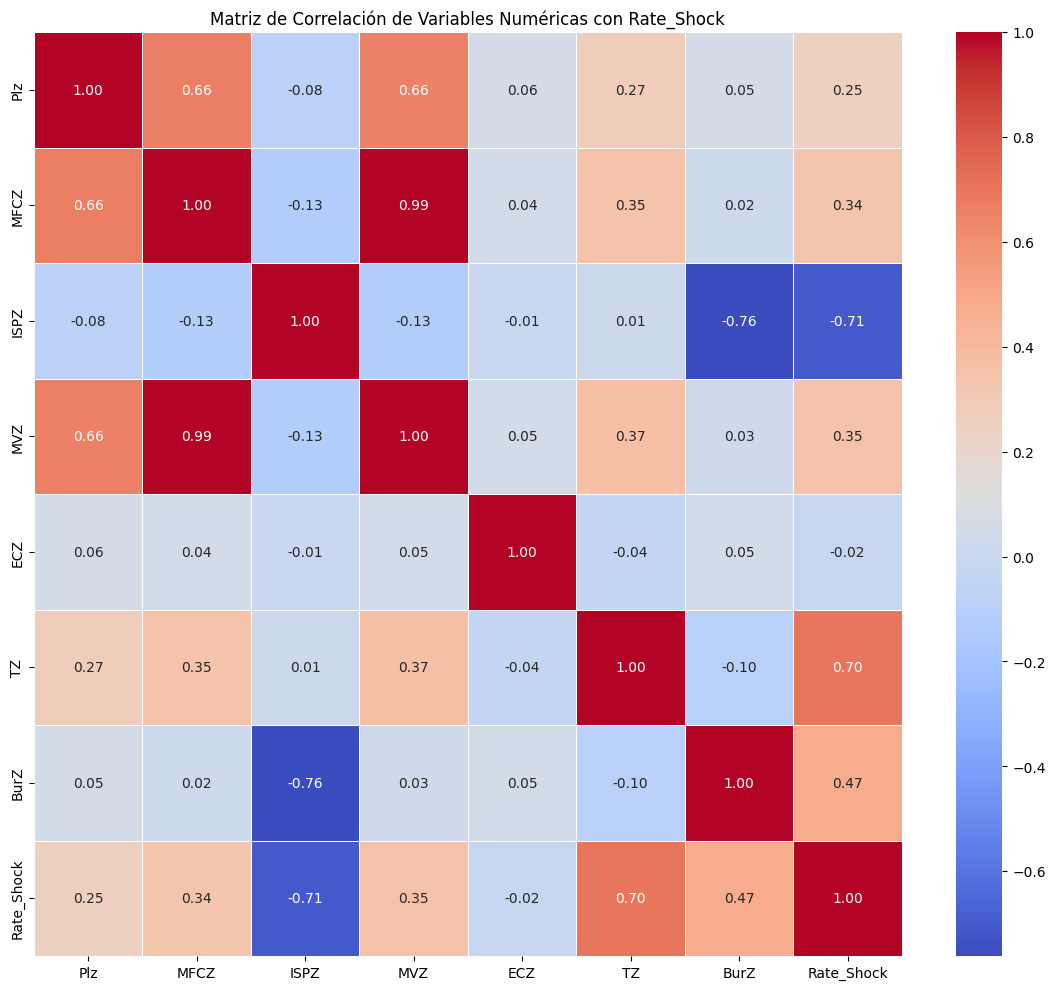

--------------------------------------------------
Correlaciones de 'Rate_Shock' con otras variables:
--------------------------------------------------


,Rate_Shock
Rate_Shock,1.000000
TZ,0.700613
BurZ,0.473359
MVZ,0.354495
MFCZ,0.337489
Plz,0.253895
ECZ,-0.021386
ISPZ,-0.705146


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas del DataFrame actual, incluyendo 'Rate_Shock'
numerical_df_with_rate_shock = df.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix_rate_shock = numerical_df_with_rate_shock.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_rate_shock, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas con Rate_Shock')
plt.show()

print("--------------------------------------------------")
print("Correlaciones de 'Rate_Shock' con otras variables:")
print("--------------------------------------------------")
display(correlation_matrix_rate_shock['Rate_Shock'].sort_values(ascending=False))

In [ ]:
import numpy as np

# Calculate IQR for 'Rate_Shock' to identify outliers
Q1_rate_shock = df['Rate_Shock'].quantile(0.25)
Q3_rate_shock = df['Rate_Shock'].quantile(0.75)
IQR_rate_shock = Q3_rate_shock - Q1_rate_shock

lower_bound_rate_shock = Q1_rate_shock - 1.5 * IQR_rate_shock
upper_bound_rate_shock = Q3_rate_shock + 1.5 * IQR_rate_shock

# Count outliers in 'Rate_Shock'
outliers_rate_shock = df[(df['Rate_Shock'] < lower_bound_rate_shock) | (df['Rate_Shock'] > upper_bound_rate_shock)]
num_outliers_rate_shock = outliers_rate_shock.shape[0]

total_records_rate_shock = df.shape[0]
percentage_outliers_rate_shock = (num_outliers_rate_shock / total_records_rate_shock) * 100 if total_records_rate_shock > 0 else 0

print("--------------------------------------------------")
print("Porcentaje de Outliers para la columna 'Rate_Shock' (Método IQR):")
print("--------------------------------------------------")
print(f"Columna 'Rate_Shock':")
print(f"  Número de outliers: {num_outliers_rate_shock}")
print(f"  Porcentaje de outliers: {percentage_outliers_rate_shock:.2f}%")
print("--------------------------------------------------")

--------------------------------------------------
Porcentaje de Outliers para la columna 'Rate_Shock' (Método IQR):
--------------------------------------------------
Columna 'Rate_Shock':
  Número de outliers: 148
  Porcentaje de outliers: 5.22%
--------------------------------------------------


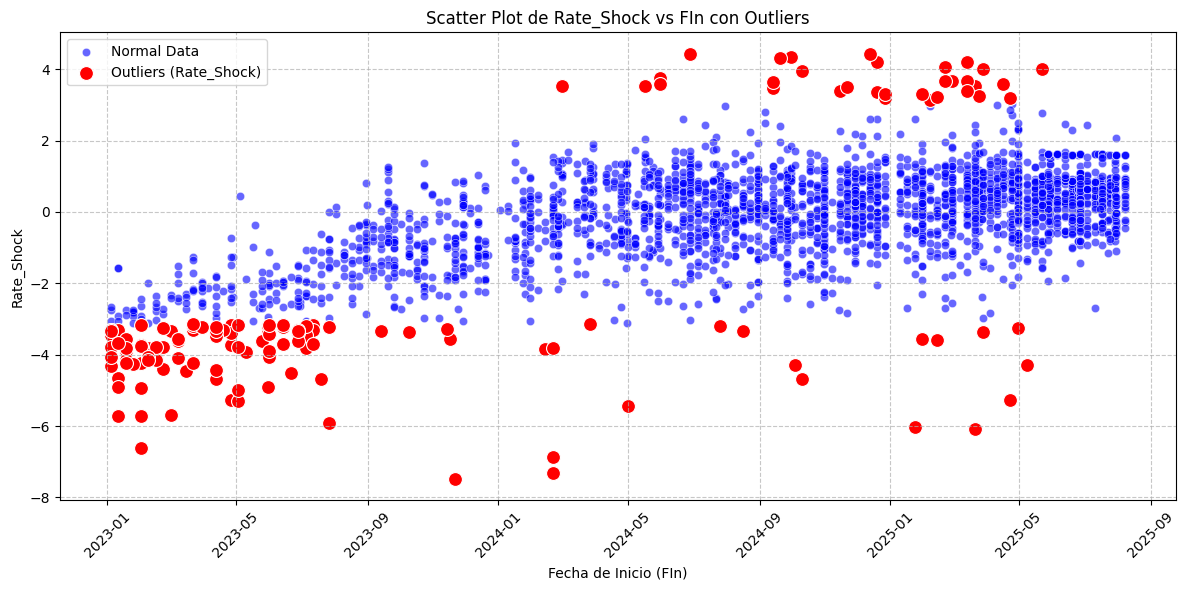

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure 'FIn' is in datetime format
df['FIn'] = pd.to_datetime(df['FIn'])

# Calculate IQR for 'Rate_Shock' to identify outliers
# Re-calculating to ensure variables are in scope for this cell, though they were already calculated.
Q1_rate_shock = df['Rate_Shock'].quantile(0.25)
Q3_rate_shock = df['Rate_Shock'].quantile(0.75)
IQR_rate_shock = Q3_rate_shock - Q1_rate_shock

lower_bound_rate_shock = Q1_rate_shock - 1.5 * IQR_rate_shock
upper_bound_rate_shock = Q3_rate_shock + 1.5 * IQR_rate_shock

# Identify outliers for 'Rate_Shock'
outliers_rate_shock = df[(df['Rate_Shock'] < lower_bound_rate_shock) | (df['Rate_Shock'] > upper_bound_rate_shock)]

plt.figure(figsize=(12, 6))
sns.scatterplot(x='FIn', y='Rate_Shock', data=df, color='blue', alpha=0.6, label='Normal Data')
sns.scatterplot(x='FIn', y='Rate_Shock', data=outliers_rate_shock, color='red', s=100, label='Outliers (Rate_Shock)')
plt.title('Scatter Plot de Rate_Shock vs FIn con Outliers')
plt.xlabel('Fecha de Inicio (FIn)')
plt.ylabel('Rate_Shock')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()